# Mock Data Vector with Optical Selection Effects

Forward model for the Buzzard-like DES Y3 cluster mock including:

1. Intrinsic mass–richness relation from Costanzi et al. 2026, Eq. 15
   (DES-Y1 NC+3x2pt best fit).
2. Projection of $\lambda_\mathrm{true}\to\lambda_\mathrm{obs}$ via the
   Costanzi+2019 Eq. 6 mixture (Gaussian core + EMG projection tail).
3. Catalog-driven optical-selection bias on the lensing profile —
   stacking on redMaPPer `LAMBDA_CHISQ`/`Z_LAMBDA` and dividing by a
   mass-redshift-matched random reference (Wu+2022 / Costanzi+2026).

Outputs:

- $N(\lambda_\mathrm{obs}, z_\mathrm{obs})$ binned number counts (forward
  model side).
- $\langle\gamma_t(R)\,|\,\lambda^\mathrm{RM}, z^\mathrm{RM}\rangle$
  stacked tangential shear and the empirical
  $\mathcal{B}_\mathrm{sel}^\mathrm{emp}(R)
  = \langle\Delta\Sigma\rangle_\mathrm{selected}/\langle\Delta\Sigma\rangle_\mathrm{mass\text{-}matched}$.

Boost-factor contamination is not yet included.

In [22]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), "src"))

import os
import fitsio
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator
from scipy.special import erfc
from astropy.table import Table, join
from astropy.cosmology import FlatLambdaCDM

from fileLoc import FileLocs
import radial_bins_phys_mpc as rbp

matplotlib.rc('xtick', labelsize=16, top=True, direction='in')
matplotlib.rc('ytick', labelsize=16, right=True, direction='in')
matplotlib.rc('axes', linewidth=1, labelsize=16)

## 1. Inputs

Everything the user can tune lives here.

In [23]:
# --- Cosmology --------------------------------------------------------
cosmo0 = FlatLambdaCDM(H0=70, Om0=0.3, Ob0=0.046, Tcmb0=2.725)

# --- Mass-richness / HOD parameters (Costanzi Eq. 15, DES-Y1 best fit).
# These are hard-coded inside costanzi_selection.py.
from costanzi_selection import (
    M_MIN, ALPHA, M_1, M_PIVOT, SIGM_INTR, EPSI, PIVOT_Z0,
    l_sat, l_tr, sig_intr, pltr_M,
    sample_lambda_true, sample_lambda_obs, projection_params,
    load_prj_interpolators, load_prj_posterior_mean,
)
print('DES-Y1 params: log10 M_min=%.4f  alpha=%.4f  log10 M_1=%.4f  sig_intr=%.4f  eps=%.4f  z_piv=%.4f'
      % (np.log10(M_MIN), ALPHA, np.log10(M_1), SIGM_INTR, EPSI, PIVOT_Z0))

# --- Projection-param file: posterior-mean collapse.
PRJ_FILE = os.path.join(os.getcwd(), 'data', 'prj_params_DESY3_lss_lin_dep_getdist_v1.txt')
PRJ_INTERP = load_prj_posterior_mean(PRJ_FILE) #get interpolators for projection parameters at any z

# --- Selection + binning (match createDataVector.ipynb edges) --------
ZMIN, ZMAX, LOGM_MIN = 0.2, 0.65, 13.0
LBDBINS  = np.array([5, 15, 25, 40, 160])
ZMIN_LIST = np.array([0.20, 0.37, 0.51])
ZMAX_LIST = np.array([0.32, 0.51, 0.64])

RNG = np.random.default_rng(seed=42)

DES-Y1 params: log10 M_min=11.3853  alpha=0.8587  log10 M_1=12.6964  sig_intr=0.1809  eps=0.2839  z_piv=0.4544


## 2. Load halo catalogue and $\Delta\Sigma$ profiles

Same selection as `0-MakeMock.ipynb`: `pid == -1`, $0 \le \cos i \le 1$,
drop the $0.33 \le z \le 0.37$ simulation-box seam, then require
$0.2 \le z \le 0.65$ and $\log M_\mathrm{vir} \ge 13$.

In [24]:
floc = FileLocs(machine='nersc')

data_h, _ = fitsio.read(floc.halo_run_fname, header=True)
data,   _ = fitsio.read(floc.profile_output_fname, header=True)

select_good = (
    (data['pid'] == -1)
    & (data['cosi'] >= 0) & (data['cosi'] <= 1)
    & ((data['redshift'] < 0.33) | (data['redshift'] > 0.37))
)

redshift_sg = data['redshift'][select_good]
logMvir_sg  = np.log10(data['Mvir'])[select_good]

sel = (redshift_sg >= ZMIN) & (redshift_sg <= ZMAX) & (logMvir_sg >= LOGM_MIN)

_mock   = Table(data[select_good][sel])
_data_h = Table(data_h); _data_h.rename_column('HALOID', 'haloid')
mock    = join(_mock, _data_h)
print('Number of halos in mock: %i' % len(mock))

data = data_h = _mock = _data_h = None

# Print column names in mock
print(mock.colnames)

Number of halos in mock: 583043
['haloid', 'Mvir', 'redshift', 'cosi', 'pid', 'rs', 'M200m', 'R200m', 'Sigma', 'DeltaSigma', 'rho', 'M200', 'R200', 'MEM_MATCH_ID', 'RA', 'DEC', 'Z', 'Z_COS', 'P_BCG', 'Z_LAMBDA', 'LAMBDA_CHISQ', 'LAMBDA_CHISQ_E', 'LAMBDA_CHISQ_ZORIG', 'SCALEVAL', 'LAMBDA_ZRED', 'LAMBDA_ZRED_E', 'MASKFRAC', 'GEOMASKFRAC', 'R_LAMBDA', 'R_MASK', 'Z_LAMBDA_E', 'NCROSS', 'Z_LAMBDA_NITER', 'DLAMBDA_DZ', 'DLAMBDA_DZ2', 'DLAMBDAVAR_DZ', 'DLAMBDAVAR_DZ2', 'C_LAMBDA', 'C_LAMBDA_ERR', 'MAG_LAMBDA_ERR', 'PZBINS', 'PZ', 'Z_LAMBDA_RAW', 'Z_LAMBDA_E_RAW', 'BCG_SPEC_Z', 'LIM_EXPTIME', 'LIM_LIMMAG_DERED', 'LIM_LIMMAG', 'LIM_LIMMAG_HARD', 'MU_STAR', 'MU_STAR_ERR']


In [25]:
header = fitsio.read_header(floc.profile_output_fname)
print(repr(header))

header_ext1 = fitsio.read_header(floc.profile_output_fname, ext=1)
print(repr(header_ext1))


SIMPLE  =                    T / conforms to FITS standard
BITPIX  =                    8 / array data type
NAXIS   =                    0 / number of array dimensions
EXTEND  =                    T / 

XTENSION= 'BINTABLE'           / binary table extension
BITPIX  =                    8 / array data type
NAXIS   =                    2 / number of array dimensions
NAXIS1  =                  368 / length of dimension 1
NAXIS2  =              1418121 / length of dimension 2
PCOUNT  =                    0 / number of group parameters
GCOUNT  =                    1 / number of groups
TFIELDS =                   11 / number of table fields
TTYPE1  = 'haloid'             / 
TFORM1  = 'J'                  / 
TTYPE2  = 'Mvir'               / 
TFORM2  = 'E'                  / 
TUNIT2  = 'Msun/h'             / 
TTYPE3  = 'redshift'           / 
TFORM3  = 'D'                  / 
TTYPE4  = 'cosi'               / 
TFORM4  = 'D'                  / 
TUNIT4  = '-1 or -2: bad halo; -10: not meausred.

### Photo-$z$ proxy

To mimic the DES Y3 photometric-redshift uncertainty we add a Gaussian
scatter to the true halo redshift:

$$
z^\mathrm{ob} = z^\mathrm{tr} + \sigma_z\,(1 + z^\mathrm{tr})\,\mathcal{N}(0,1),
\qquad \sigma_z = 0.01,
$$

clipped at $z^\mathrm{ob} \ge 0.02$ to avoid unphysical negatives. This is a
simplified stand-in for the redshift- and color-dependent kernel of
Myles+2021; it captures the dominant scatter but not the tails. Throughout
the rest of the notebook, $\lambda^\mathrm{ob}$ is drawn at $z^\mathrm{ob}$
and all binning uses $z^\mathrm{ob}$ to stay consistent with the
observed-frame projection.

In [26]:
# Add a Gaussian photo-z proxy for DES Y3-like uncertainty.
# (A more accurate photo-z kernel — Myles+2021 — would be redshift- and color-
#  dependent, but this captures the dominant scatter.)
SIGMA_Z_FRAC = 0.01   # fractional photo-z scatter, DES Y3-like
mock['redshift_true'] = mock['redshift'].copy()
mock['redshift_obs']  = mock['redshift'] + SIGMA_Z_FRAC * (1.0 + mock['redshift']) \
                                          * RNG.standard_normal(size=len(mock))
mock['redshift_obs']  = np.clip(mock['redshift_obs'], 0.02, None)

## 3. $\lambda_\mathrm{true}$ from Costanzi Eq. 15

$\langle\lambda_\mathrm{true}|M,z\rangle = 1 + \left(\tfrac{M-M_\mathrm{min}}{M_\mathrm{pivot}}\right)^{\alpha}\,\left(\tfrac{1+z}{1+z_\mathrm{piv}}\right)^{\epsilon}$,

with intrinsic scatter $\sigma_\mathrm{intr}\,\ell_\mathrm{sat}(M,z)$ and
$P(\lambda_\mathrm{true}|M,z)$ a compound-Poisson+lognormal law (`pltr_M`).

mean lambda_true: 5.497608238157391
fraction lambda_true >= 5 : 0.46304131942240967
fraction lambda_true >= 20: 0.020658853635152123


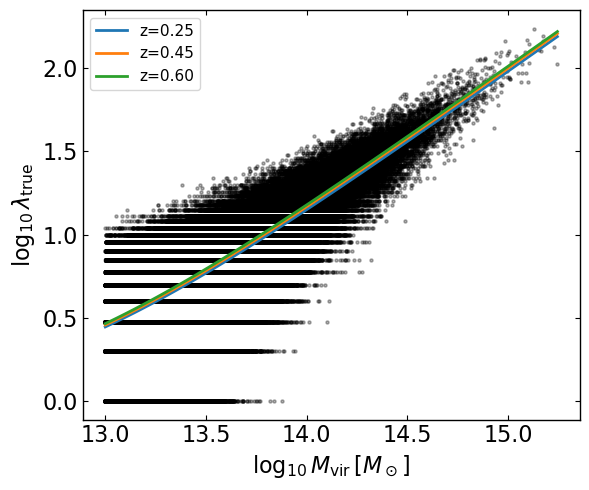

In [27]:
Mvir = np.asarray(mock['Mvir'], dtype=float)
zcl  = np.asarray(mock['redshift'], dtype=float)

lambda_true = sample_lambda_true(Mvir, zcl, rng=RNG).astype(float)
mock['lambda_true'] = lambda_true

print('mean lambda_true:', lambda_true.mean())
print('fraction lambda_true >= 5 :', (lambda_true >= 5).mean())
print('fraction lambda_true >= 20:', (lambda_true >= 20).mean())

# Sanity: expected mean relation vs sampled halos.
logM = np.log10(Mvir)
fig, ax = plt.subplots(figsize=(6, 5))
# ax.hexbin(logM, np.log10(np.clip(lambda_true, 1, None)), gridsize=60,
#           mincnt=1, cmap='Greys')
ax.scatter(logM, np.log10(np.clip(lambda_true, 1, None)), alpha=0.3, s=5, color='k')
mg = np.linspace(logM.min(), logM.max(), 80)
for zref in [0.25, 0.45, 0.60]:
    ax.plot(mg, np.log10(l_tr(10**mg, zref)), lw=2, label='z=%.2f' % zref)
ax.set_xlabel(r'$\log_{10} M_\mathrm{vir}\,[M_\odot]$')
ax.set_ylabel(r'$\log_{10} \lambda_\mathrm{true}$')
ax.legend(fontsize=11); fig.tight_layout()

Show the scatter of the sampled intrinsic richness, $\lambda_{\rm true}$, around the expected mean richness--mass relation:

$$
\log_{10}\left(
\frac{\lambda_{\rm true}}
{\langle \lambda_{\rm true} \mid M, z_{\rm ref} \rangle}
\right).
$$

The distribution is not symmetric in log space, and because the halo catalogue is dominated by low-richness halos so there is tail at lower richness.

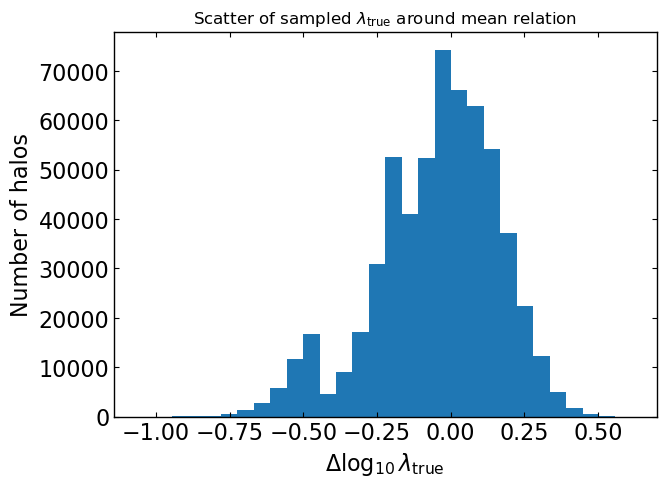

In [28]:
plt.figure(figsize=(7, 5))

# Compare each sampled lambda_true to the mean relation evaluated at that
# halo's own redshift, not at a single reference z.
plt.hist(
    np.log10(np.clip(lambda_true, 1, None)) - np.log10(l_tr(Mvir, zcl)),
    bins=30
)

plt.xlabel(r'$\Delta \log_{10} \lambda_{\rm true}$')
plt.ylabel('Number of halos')
plt.title(r'Scatter of sampled $\lambda_{\rm true}$ around mean relation')

plt.show()

In [29]:
np.log10(l_tr(Mvir, zcl))

array([1.02008459, 0.6307012 , 1.02423139, ..., 0.46835689, 0.52477553,
       0.48750511], shape=(583043,))

## 4. Project $\lambda_\mathrm{true} \to \lambda_\mathrm{obs}$

Costanzi+2019, Eq. 6 ([arXiv:1807.07072](https://arxiv.org/abs/1807.07072)):

$$
P(\lambda_\mathrm{obs}|\lambda_\mathrm{true},z) =
(1 - f_\mathrm{prj})\,\mathcal{N}(\mu,\sigma) +
f_\mathrm{prj}\,\frac{\tau}{2}\,
\exp\!\left[\frac{\tau}{2}(2\mu + \tau\sigma^2 - 2\lambda_\mathrm{obs})\right]\,
\mathrm{erfc}\!\left(\frac{\mu + \tau\sigma^2 - \lambda_\mathrm{obs}}{\sqrt{2}\,\sigma}\right),
$$

with $\mu = \mu(\lambda_\mathrm{true}, z)$ a linear function of $\lambda_\mathrm{true}$,
$\sigma = \sigma(\lambda_\mathrm{true}, z)$ a power law, $f_\mathrm{prj}$ a sigmoid,
and $\tau$ a power law. All four parameters are evaluated from the
SDSS-calibrated posterior-mean coefficients in
`prj_params_DESY3_lss_lin_dep_getdist_v1.txt` via `projection_params`.

The mixture is sampled directly: with probability $1-f_\mathrm{prj}$ we draw
from the Gaussian; with probability $f_\mathrm{prj}$ we draw from the
exponentially-modified Gaussian as `N(mu, sigma) + Exp(1/tau)` (sum of
independent draws — the EMG closed form is the convolution of these two).

In [30]:
# --- Sample lambda_obs from Costanzi+2019 Eq. 6 ---
zcl_for_projection = np.asarray(mock['redshift_obs'], dtype=float)  # was 'redshift'
lambda_obs, f_prj, tau, mu_prj, sig_prj = sample_lambda_obs(
    lambda_true, zcl_for_projection, PRJ_INTERP, rng=RNG)

mock['lambda_obs'] = lambda_obs
mock['f_prj']      = f_prj
mock['tau_prj']    = tau
mock['mu_prj']     = mu_prj
mock['sig_prj']    = sig_prj

assert len(lambda_obs) == len(lambda_true)

dlam = lambda_obs - lambda_true
print('<lambda_true>           = %.3f' % lambda_true.mean())
print('<lambda_obs>            = %.3f' % lambda_obs.mean())
print('<Delta lambda>          = %.3f' % dlam.mean())
print('<f_prj>                 = %.3f' % f_prj.mean())
print('<1/tau>                 = %.3f' % np.mean(1.0 / tau))
print('<sigma>                 = %.3f' % sig_prj.mean())
print('<mu - lambda_true>      = %.3f' % (mu_prj - lambda_true).mean())

<lambda_true>           = 5.498
<lambda_obs>            = 5.497
<Delta lambda>          = -0.000
<f_prj>                 = 0.608
<1/tau>                 = 1.622
<sigma>                 = 2.375
<mu - lambda_true>      = -1.100


### Sanity: do MC draws of $\lambda^\mathrm{ob}$ recover the analytical kernel?

Histogram repeated `sample_lambda_obs` draws at fixed $(\lambda^\mathrm{tr}, z)$ and overlay the closed-form Eq. 6 PDF. The two should match within Poisson noise.

/tmp/ipykernel_1270470/4157574052.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


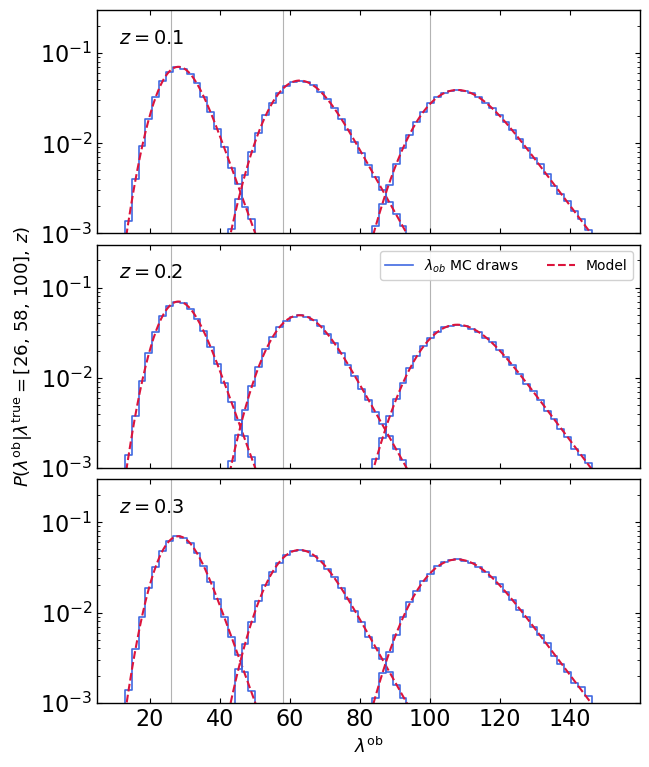

In [31]:
# --- Analytical PDF of Costanzi+2019 Eq. 6 ---------------------------------
def p_lambda_obs(lobs, ltr, z, interp):
    """
    Closed-form P(lambda_obs | lambda_true, z) from Costanzi+2019 Eq. 6.
    Evaluated point-wise: lobs (nr,), ltr scalar, z scalar.
    """
    f_prj, tau, mu, sigma = projection_params(np.asarray(ltr, float),
                                              np.asarray(z, float),
                                              interp)
    f_prj = float(f_prj); tau = float(tau); mu = float(mu); sigma = float(sigma)

    # Gaussian branch
    gauss = (1.0 / (np.sqrt(2.0 * np.pi) * sigma)) * np.exp(
        -0.5 * ((lobs - mu) / sigma) ** 2)

    # EMG branch — closed form. Compute the log first to avoid overflow in exp.
    a   = mu + tau * sigma ** 2 - lobs
    log_pref = np.log(tau / 2.0) + (tau / 2.0) * (2.0 * mu + tau * sigma ** 2 - 2.0 * lobs)
    emg = np.exp(log_pref) * erfc(a / (np.sqrt(2.0) * sigma))

    return (1.0 - f_prj) * gauss + f_prj * emg

# --- Settings ---
LTR_FIX = [26, 58, 100]
Z_FIX   = [0.1, 0.2, 0.3]
N_DRAWS = 200_000
BINS    = np.linspace(5, 160, 80)
BCEN    = 0.5 * (BINS[:-1] + BINS[1:])

# --- Plot ---
fig, axes = plt.subplots(len(Z_FIX), 1, figsize=(7, 9),
                          sharex=True, sharey=True,
                          gridspec_kw={'hspace': 0.05})

rng_plot = np.random.default_rng(seed=123)

for irow, z0 in enumerate(Z_FIX):
    ax = axes[irow]
    for ltr0 in LTR_FIX:
        ltr_arr = np.full(N_DRAWS, ltr0, dtype=float)
        z_arr   = np.full(N_DRAWS, z0,   dtype=float)

        lobs_draw, *_ = sample_lambda_obs(ltr_arr, z_arr, PRJ_INTERP, rng=rng_plot)

        hist, _ = np.histogram(lobs_draw, bins=BINS, density=True)
        ax.step(BCEN, hist, where='mid', color='royalblue', lw=1.2,
                label=(r'$\lambda_{ob}$ MC draws'
                       if (irow == 1 and ltr0 == LTR_FIX[0]) else None))

        x = np.linspace(BINS[0], BINS[-1], 600)
        pdf = p_lambda_obs(x, ltr0, z0, PRJ_INTERP)
        ax.plot(x, pdf, '--', color='crimson', lw=1.5,
                label=('Model' if (irow == 1 and ltr0 == LTR_FIX[0]) else None))

        ax.axvline(ltr0, color='0.7', lw=0.8, zorder=0)

    ax.set_yscale('log')
    ax.set_ylim(1e-3, 3e-1)
    ax.set_xlim(5, 160)
    ax.text(0.04, 0.85, r'$z = %.1f$' % z0,
            transform=ax.transAxes, fontsize=14)

    if irow == 1:
        ax.legend(loc='upper right', fontsize=10, ncol=2,
                  frameon=True, framealpha=0.9)

# One y-label on the middle row
axes[1].set_ylabel(
    r'$P(\lambda^{\rm ob}|\lambda^{\rm true} = [26,\,58,\,100],\,z)$',
    fontsize=13,
)
axes[-1].set_xlabel(r'$\lambda^{\rm ob}$', fontsize=13)

# Linear x-axis ticks
for ax in axes:
    ax.xaxis.set_major_locator(FixedLocator([20, 40, 60, 80, 100, 120, 140]))
    ax.tick_params(axis='both', which='both', direction='in',
                   top=True, right=True)

fig.tight_layout()
plt.show()

### Decompose the kernel into Gaussian core + EMG projection tail

Same Eq. 6, split into the two physical components — at large $\lambda^\mathrm{tr}$ the EMG tail dominates the high-$\lambda^\mathrm{ob}$ side and drives the projection bias.

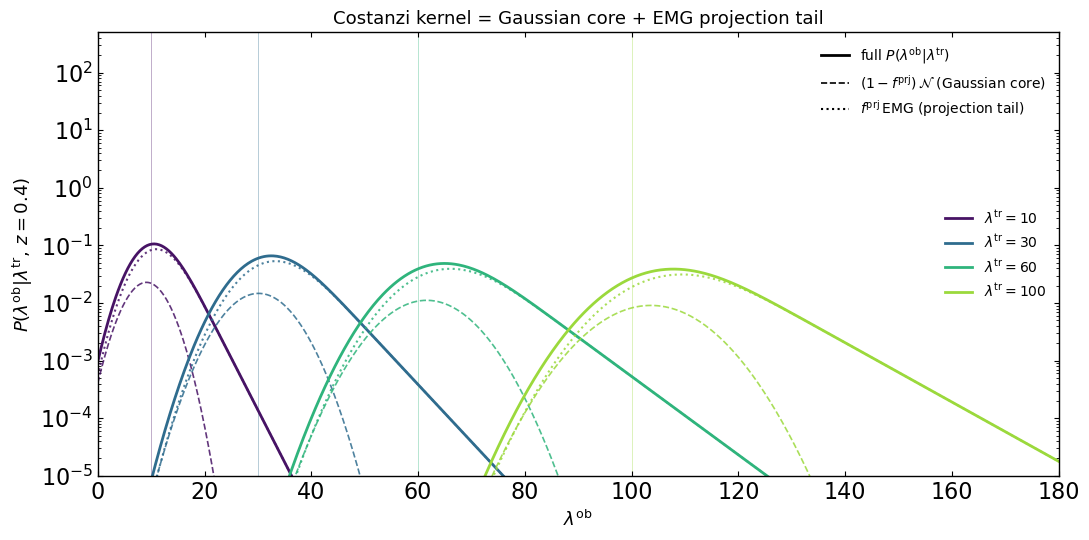

In [32]:
# --- Decomposed PDF: returns (gauss_core, emg_tail, total) at given lobs grid ---
def p_lambda_obs_decomposed(lobs, ltr, z, interp):
    """
    Returns the two components of Costanzi+2019 Eq. 6 separately:

        gauss_core  = (1 - f_prj) * N(mu, sigma)
        emg_tail    = f_prj * EMG(mu, sigma, tau)
        total       = gauss_core + emg_tail

    Each output has the same shape as `lobs`.
    """
    f_prj, tau, mu, sigma = projection_params(np.asarray(ltr, float),
                                              np.asarray(z, float),
                                              interp)
    f_prj = float(f_prj); tau = float(tau); mu = float(mu); sigma = float(sigma)

    # Gaussian component
    gauss = (1.0 / (np.sqrt(2.0 * np.pi) * sigma)) * np.exp(
        -0.5 * ((lobs - mu) / sigma) ** 2)

    # EMG component — compute log first to avoid overflow in the exponential.
    a = mu + tau * sigma ** 2 - lobs
    log_pref = np.log(tau / 2.0) + (tau / 2.0) * (2.0 * mu + tau * sigma ** 2 - 2.0 * lobs)
    emg = np.exp(log_pref) * erfc(a / (np.sqrt(2.0) * sigma))

    gauss_core = (1.0 - f_prj) * gauss
    emg_tail   = f_prj * emg
    total      = gauss_core + emg_tail
    return gauss_core, emg_tail, total


# --- Plot ---
LTR_LIST = [10, 30, 60, 100]
Z_FIX    = 0.4

# Viridis-like color sequence matching the reference plot
cmap = plt.get_cmap('viridis')
colors = [cmap(0.05), cmap(0.35), cmap(0.65), cmap(0.85)]

fig, ax = plt.subplots(figsize=(11, 5.5))

x = np.linspace(0.01, 180, 800)

for ltr0, c in zip(LTR_LIST, colors):
    gauss_core, emg_tail, total = p_lambda_obs_decomposed(x, ltr0, Z_FIX, PRJ_INTERP)

    ax.plot(x, total,      '-',  lw=2.0, color=c, label=r'$\lambda^{\rm tr}=%i$' % ltr0)
    ax.plot(x, gauss_core, '--', lw=1.2, color=c, alpha=0.85)
    ax.plot(x, emg_tail,   ':',  lw=1.5, color=c, alpha=0.85)

    ax.axvline(ltr0, color=c, lw=0.6, alpha=0.4, zorder=0)

ax.set_yscale('log')
ax.set_xlim(0, 180)
ax.set_ylim(1e-5, 5e2)
ax.set_xlabel(r'$\lambda^{\rm ob}$', fontsize=13)
ax.set_ylabel(r'$P(\lambda^{\rm ob}|\lambda^{\rm tr},\,z=%.1f)$' % Z_FIX, fontsize=13)
ax.set_title('Costanzi kernel = Gaussian core + EMG projection tail', fontsize=13)

# Two legends: one for the component linestyles (top right area),
# one for the lambda_true colors (mid right). Use proxy artists so
# the linestyle legend isn't tied to a specific color.
style_handles = [
    Line2D([], [], color='k', ls='-',  lw=2.0, label=r'full $P(\lambda^{\rm ob}|\lambda^{\rm tr})$'),
    Line2D([], [], color='k', ls='--', lw=1.2, label=r'$(1-f^{\rm prj})\,\mathcal{N}$ (Gaussian core)'),
    Line2D([], [], color='k', ls=':',  lw=1.5, label=r'$f^{\rm prj}\,$EMG (projection tail)'),
]
leg_style = ax.legend(handles=style_handles, loc='upper right',
                       fontsize=10, frameon=False)
ax.add_artist(leg_style)
ax.legend(loc='center right', fontsize=10, frameon=False, title=None)

ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
fig.tight_layout()
plt.show()

## 5. Output 1 — $N(\lambda_\mathrm{obs}, z)$

In [33]:
def compute_number_counts(x, z, xbins, zmin_list, zmax_list):
    counts = []
    for xl, xh in zip(xbins[:-1], xbins[1:]):
        xmask = (x >= xl) & (x < xh)
        row = []
        for zl, zh in zip(zmin_list, zmax_list):
            row.append(int(np.count_nonzero(xmask & (z >= zl) & (z < zh))))
        counts.append(row)
    return np.array(counts)

# Bin on the observed (photo-z) redshift to be consistent with the
# observed-frame projection used to draw lambda_obs.
nc_obs = compute_number_counts(np.asarray(mock['lambda_obs']),
                                np.asarray(mock['redshift_obs']),
                                LBDBINS, ZMIN_LIST, ZMAX_LIST)
print('N(lambda_obs, z_obs):')
print(nc_obs)

N(lambda_obs, z_obs):
[[28903 71482 90166]
 [ 4138  9419 11699]
 [ 1242  2739  3120]
 [  482   941   903]]


## 6. Stacked $\Sigma(R)$ in $\lambda$ bins: true vs observed

The lensing data vector is built by **stacking** — averaging $\Sigma(R)$ over halos in each $(\lambda, z)$ bin:

$$
\langle\Sigma(R) \mid \lambda \in [\lambda_1, \lambda_2),\, z \in [z_1, z_2)\rangle
= \frac{1}{N_\mathrm{bin}}\sum_{i \in \mathrm{bin}} \Sigma_i(R).
$$

Each halo's $\Sigma_i(R)$ is set by its mass via the NFW-like projected profile, so the stacked profile is shaped by the **mass distribution within the bin**.

Comparing two stacks at the same numerical $\lambda$ — one binned on $\lambda^\mathrm{tr}$, one on $\lambda^\mathrm{ob}$ — reveals how optical selection alters that mass distribution:

- The $\lambda^\mathrm{tr}$ bin contains halos whose intrinsic richness lies in the range, so it samples a narrow mass range set by the Costanzi mass-richness relation.
- The $\lambda^\mathrm{ob}$ bin additionally sweeps in low-mass halos that got projection-boosted up into the range via the asymmetric Costanzi+2019 Eq. 6 kernel.

So $\langle\Sigma|\lambda^\mathrm{ob}\rangle < \langle\Sigma|\lambda^\mathrm{tr}\rangle$ is expected: the $\lambda^\mathrm{ob}$ bin pulls in extra low-mass halos via the projection tail, dragging the mean mass — and hence the mean $\Sigma$ — below the $\lambda^\mathrm{tr}$ stack. This is the **mass-dilution** (Eddington-like) piece of the optical-selection effect that the forward model captures.

Halos per (lambda_true bin, z bin):
[[ 34093  84812 107207]
 [  2910   6426   7720]
 [   861   1822   2023]
 [   317    559    513]]
Halos per (lambda_obs bin, z bin):
[[28903 71482 90166]
 [ 4138  9419 11699]
 [ 1242  2739  3120]
 [  482   941   903]]


/tmp/ipykernel_1270470/3661610003.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


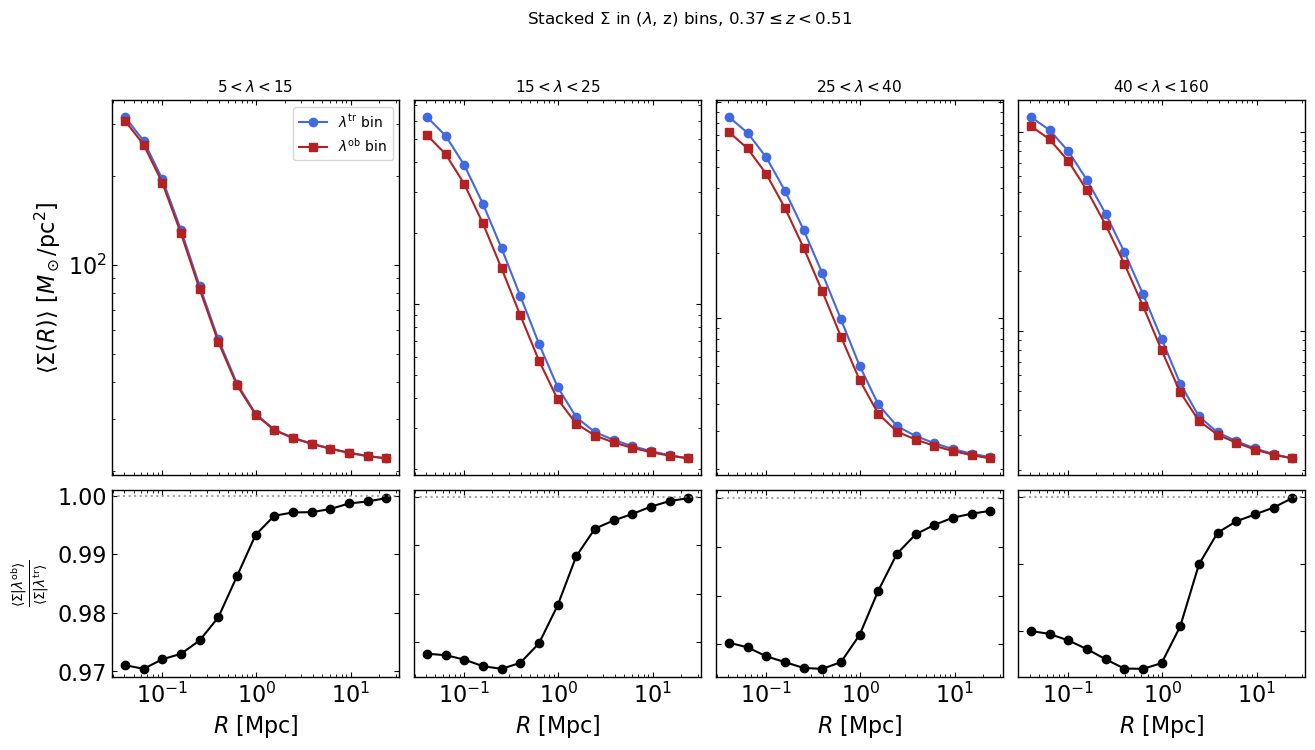

In [34]:
radii = rbp.rp_phys_mpc        # physical Mpc (no h)

# --- Inputs ----------------------------------------------------------------
ltr_arr   = np.asarray(mock['lambda_true'])
lob_arr   = np.asarray(mock['lambda_obs'])
zob_arr   = np.asarray(mock['redshift_obs'])     # bin on observed z (photo-z)
Sigma_arr = np.asarray(mock['Sigma'])            # (nh, nr)

# --- Stack Sigma in (lambda, z) bins ---------------------------------------
def stack_sigma(lam, z, Sigma, lam_bins, z_min_list, z_max_list):
    """
    Returns mean Sigma profile per (lam_bin, z_bin), shape (nl, nz, nr),
    plus halo counts per bin, shape (nl, nz).
    """
    nl = len(lam_bins) - 1
    nz = len(z_min_list)
    nr = Sigma.shape[1]
    mean_Sigma = np.zeros((nl, nz, nr))
    counts     = np.zeros((nl, nz), dtype=int)

    for il in range(nl):
        in_lam = (lam >= lam_bins[il]) & (lam < lam_bins[il + 1])
        for iz in range(nz):
            in_z = (z >= z_min_list[iz]) & (z < z_max_list[iz])
            m = in_lam & in_z
            n = int(m.sum())
            counts[il, iz] = n
            if n > 0:
                mean_Sigma[il, iz] = Sigma[m].mean(axis=0)
    return mean_Sigma, counts


Sigma_ltr, N_ltr = stack_sigma(ltr_arr, zob_arr, Sigma_arr, LBDBINS, ZMIN_LIST, ZMAX_LIST)
Sigma_lob, N_lob = stack_sigma(lob_arr, zob_arr, Sigma_arr, LBDBINS, ZMIN_LIST, ZMAX_LIST)

print("Halos per (lambda_true bin, z bin):")
print(N_ltr)
print("Halos per (lambda_obs bin, z bin):")
print(N_lob)

# --- Plot ------------------------------------------------------------------
nl = len(LBDBINS) - 1
nz = len(ZMIN_LIST)
zb = 1   # which redshift bin to show; change to taste

fig, axes = plt.subplots(2, nl, figsize=(nl * 3.6 + 1, 7.5),
                          sharex=True,
                          gridspec_kw={'hspace': 0.05, 'wspace': 0.05,
                                       'height_ratios': [3, 1.5]})

for il in range(nl):
    ax_top = axes[0, il]
    ax_bot = axes[1, il]

    s_tr = Sigma_ltr[il, zb]
    s_ob = Sigma_lob[il, zb]

    # Top: stacked Sigma profiles
    ax_top.loglog(radii, s_tr, 'o-', color='royalblue',  label=r'$\lambda^{\rm tr}$ bin')
    ax_top.loglog(radii, s_ob, 's-', color='firebrick',  label=r'$\lambda^{\rm ob}$ bin')
    ax_top.set_title(r'$%i < \lambda < %i$' % (LBDBINS[il], LBDBINS[il + 1]),
                     fontsize=11)

    # Bottom: ratio
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(s_tr > 0, s_ob / s_tr, np.nan)
    ax_bot.semilogx(radii, ratio, 'o-', color='black')
    ax_bot.axhline(1.0, ls=':', color='gray', alpha=0.7)

    ax_bot.set_xlabel(r'$R\ [{\rm Mpc}]$')

    if il > 0:
        ax_top.tick_params(labelleft=False)
        ax_bot.tick_params(labelleft=False)

axes[0, 0].set_ylabel(r'$\langle\Sigma(R)\rangle\ [M_\odot/{\rm pc}^2]$')
axes[1, 0].set_ylabel(
    r'$\frac{\langle\Sigma | \lambda^{\rm ob}\rangle}{\langle\Sigma | \lambda^{\rm tr}\rangle}$',
    fontsize=14,
)
axes[0, 0].legend(loc='upper right', fontsize=10)

fig.suptitle(r'Stacked $\Sigma$ in ($\lambda$, z) bins, '
             r'$%.2f \leq z < %.2f$' % (ZMIN_LIST[zb], ZMAX_LIST[zb]),
             y=1.00, fontsize=12)
fig.tight_layout()
plt.show()

### Costanzi+2026 Fig. 3 comparison

Cross-check the absolute amplitude and shape of $\langle\Sigma(R | \lambda^\mathrm{ob} \!\sim\! 20, z^\mathrm{ob} \!\sim\! 0.5)\rangle$ against C26 Fig. 3, with the same axes (cMpc/h, $M_\odot/(\mathrm{Mpc}/h)^2$).

Closest bin: lambda in [15, 25),  z in [0.37, 0.51)
N halos in bin: 9419


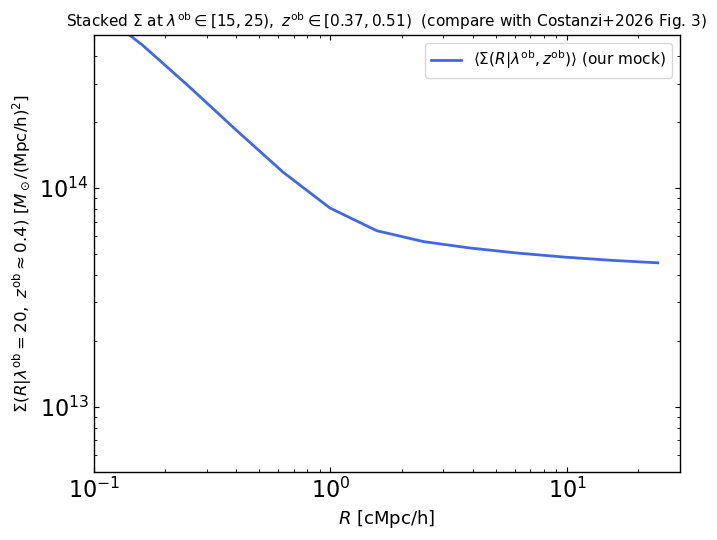

In [35]:
# --- Fig. 3 of Costanzi+2026 comparison ------------------------------------
# Their Fig. 3 shows <Sigma(R | lambda_ob=20, z_ob=0.5)> with shaded uncertainty
# from a Buzzard-like mock, decomposed into 1-halo and 2-halo terms.
#
# We can plot only the TOTAL Sigma from our mock (we don't have the 1h/2h split),
# but with the same axes and the closest matching (lambda, z) bin from our binning.

# Find the bin closest to (lambda_ob = 20, z = 0.5)
def find_bin(value, edges):
    for i in range(len(edges) - 1):
        if edges[i] <= value < edges[i + 1]:
            return i
    return len(edges) - 2

il_target = find_bin(20.0, LBDBINS)          # lambda bin containing 20
# For z, find the bin closest to 0.5 (assuming ZMIN_LIST is sorted)
iz_target = int(np.argmin(np.abs((np.array(ZMIN_LIST) + np.array(ZMAX_LIST)) / 2 - 0.5)))

print(f"Closest bin: lambda in [{LBDBINS[il_target]}, {LBDBINS[il_target+1]}),  "
      f"z in [{ZMIN_LIST[iz_target]}, {ZMAX_LIST[iz_target]})")
print(f"N halos in bin: {N_lob[il_target, iz_target]}")


# Re-stack Sigma in that one bin with per-halo errors so we can compute a band.
in_bin = ((lob_arr >= LBDBINS[il_target]) &
          (lob_arr <  LBDBINS[il_target + 1]) &
          (zob_arr >= ZMIN_LIST[iz_target])  &
          (zob_arr <  ZMAX_LIST[iz_target]))
n_bin = int(in_bin.sum())

Sigma_bin    = Sigma_arr[in_bin]                          # (n_bin, nr)
mean_Sigma   = Sigma_bin.mean(axis=0)
std_Sigma    = Sigma_bin.std(axis=0)
sem_Sigma    = std_Sigma / np.sqrt(n_bin)                  # standard error of the mean

# Convert radii to comoving Mpc/h to match Costanzi+2026 Fig. 3 axis convention.
# In their plot, x = R [cMpc/h].
h     = cosmo0.h
z_rep = float(np.mean(zob_arr[in_bin]))
R_cMpc_h = radii * (1.0 + z_rep) * h

# Convert Sigma to the same units Costanzi uses on y. Their axis runs ~1e13 to 5e14
# (likely Msun / (Mpc/h)^2 or similar). Your mock Sigma is presumably Msun/pc^2.
# 1 Msun/pc^2 = 1e12 Msun/Mpc^2. So multiply by (Mpc/h)^2 / pc^2 = 1e12 / h^2.
SIGMA_UNIT_CONV = 1e12 / h ** 2            # Msun/pc^2 -> Msun/(Mpc/h)^2
mean_y = mean_Sigma * SIGMA_UNIT_CONV
sem_y  = sem_Sigma  * SIGMA_UNIT_CONV


# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 5.5))

ax.loglog(R_cMpc_h, mean_y, '-', color='royalblue', lw=2.0,
          label=r'$\langle\Sigma(R | \lambda^{\rm ob}, z^{\rm ob})\rangle$ (our mock)')
ax.fill_between(R_cMpc_h, np.maximum(mean_y - sem_y, 1e10), mean_y + sem_y,
                color='royalblue', alpha=0.25, lw=0)

ax.set_xlim(0.1, 30)
ax.set_ylim(5e12, 5e14)
ax.set_xlabel(r'$R\ [{\rm cMpc/h}]$', fontsize=13)
ax.set_ylabel(
    r'$\Sigma(R | \lambda^{\rm ob} = %d,\ z^{\rm ob} \approx %.1f)\ [M_\odot/({\rm Mpc/h})^2]$'
    % (int(0.5 * (LBDBINS[il_target] + LBDBINS[il_target + 1])), z_rep),
    fontsize=12,
)
ax.set_title(
    r'Stacked $\Sigma$ at $\lambda^{\rm ob}\in[%d,%d),\ z^{\rm ob}\in[%.2f,%.2f)$  '
    r'(compare with Costanzi+2026 Fig. 3)' %
    (LBDBINS[il_target], LBDBINS[il_target + 1],
     ZMIN_LIST[iz_target], ZMAX_LIST[iz_target]),
    fontsize=11,
)
ax.legend(fontsize=11)
ax.tick_params(direction='in', top=True, right=True, which='both')

fig.tight_layout()
plt.show()

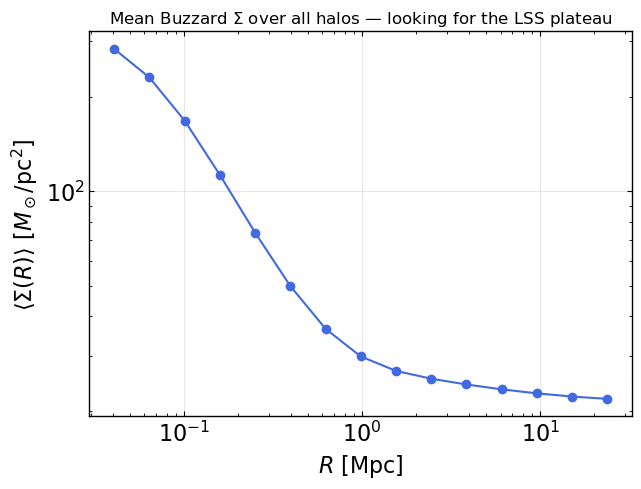

Mean Sigma at the outermost 3 radial bins (the plateau):
[22.75 22.22 21.85]


In [36]:
import matplotlib.pyplot as plt
import numpy as np

Sigma_mean = np.mean(np.asarray(mock['Sigma']), axis=0)
plt.figure(figsize=(7, 5))
plt.loglog(radii, Sigma_mean, 'o-', color='royalblue')
plt.xlabel(r'$R\ [{\rm Mpc}]$')
plt.ylabel(r'$\langle\Sigma(R)\rangle\ [M_\odot/{\rm pc}^2]$')
plt.title(r'Mean Buzzard $\Sigma$ over all halos — looking for the LSS plateau')
plt.grid(alpha=0.3)
plt.show()

# Numerical readout of the plateau region
print("Mean Sigma at the outermost 3 radial bins (the plateau):")
print(np.round(Sigma_mean[-3:], 2))

## 6.5 Diagnostic: $\lambda^\mathrm{ob}$ from the C19 formula vs `LAMBDA_CHISQ`

Two quantities both labelled $\lambda^\mathrm{ob}$ live in `mock`:

- **`mock['lambda_obs']`** — drawn from the Costanzi+2019 Eq. 6 kernel per halo. Reproduces the statistical distribution but is uncorrelated with line-of-sight structure at fixed $(M, z)$.
- **`mock['LAMBDA_CHISQ']`** — from running redMaPPer on the Buzzard photometric catalog. Per-halo richness driven by actual galaxies projected into the photo-z aperture, so it carries environment information.

Three checks to confirm both are sensible: (A) population distributions overlap; (B) per-halo values are scattered, not identical (they carry different physical content); (C) both follow Costanzi Eq. 15 mean richness–mass relation.

## 6.6 Halo mass function: Buzzard vs analytical

Sanity check on the abundance side of the data vector. Compare the binned $dn/d\log M$ from the Buzzard catalog (within the volume our redshift cuts subtend) against an analytical halo mass function from the `hmf` package, evaluated at the same cosmology and using the Bryan & Norman 1998 virial-overdensity mass convention that matches Buzzard's `Mvir`.

If the two agree to within $\sim 10\text{–}20\%$, the abundance leg of the data vector is consistent with what a halo-model prediction would expect — and any cosmology likelihood we run on the data vector won't pull the fit away from the input cosmology because of an HMF mismatch.

Effective sample volume: 1.696e+09  (Mpc/h)^3


/tmp/ipykernel_1270470/2594376966.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


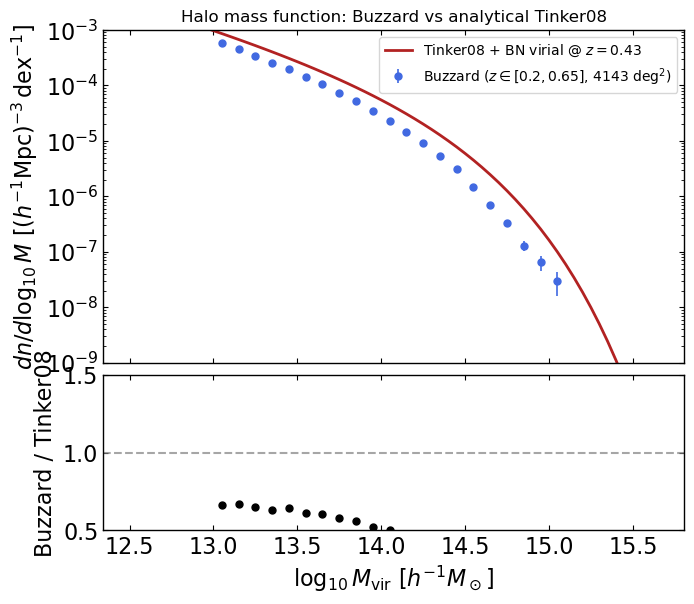

Buzzard counts per dex (first/last bin):
  log10 M = 13.05:  N =  96440,  dn/dlogM = 5.685e-04
  log10 M = 14.25:  N =   1578,  dn/dlogM = 9.302e-06
  log10 M = 15.45:  N =      0,  dn/dlogM = 0.000e+00


In [37]:
# === Section 6.6 — Buzzard HMF vs analytical (Steven Murray's `hmf`) ====
#
# The Y3 Buzzard realisation covers ~4143 deg^2 (Wu+2022 §3.1).
# Our redshift selection [0.20, 0.65] excludes [0.33, 0.37] (box seam).

import hmf
from hmf import MassFunction
from hmf.density_field.transfer_models import EH        # Eisenstein-Hu transfer
from hmf.mass_function.fitting_functions import Tinker08
from hmf.halos.mass_definitions import SOVirial          # Bryan-Norman virial

# ---------------------------------------------------------------------------
# 1. Volume probed by the sample
# ---------------------------------------------------------------------------
SKY_AREA_DEG2 = 4143.0                            # DES Y3 Buzzard area
SKY_FRAC      = SKY_AREA_DEG2 / 41252.96          # fraction of full sky
SEAM_LO, SEAM_HI = 0.33, 0.37

def comoving_volume_shell(zlo, zhi, cosmo):
    """Full-sky comoving volume between zlo and zhi, in (Mpc/h)^3."""
    Vlo = cosmo.comoving_volume(zlo).to('Mpc3').value
    Vhi = cosmo.comoving_volume(zhi).to('Mpc3').value
    return (Vhi - Vlo) * cosmo.h ** 3              # Mpc^3 -> (Mpc/h)^3

# Volume = sky-fraction × (full shell minus seam shell)
V_full = comoving_volume_shell(ZMIN, ZMAX, cosmo0)
V_seam = comoving_volume_shell(SEAM_LO, SEAM_HI, cosmo0)
V_sample_hinvMpc3 = SKY_FRAC * (V_full - V_seam)
print(f"Effective sample volume: {V_sample_hinvMpc3:.3e}  (Mpc/h)^3")


# ---------------------------------------------------------------------------
# 2. Buzzard binned dn/dlogM (per (Mpc/h)^3 per dex)
# ---------------------------------------------------------------------------
# Convert to h^-1 Msun units to match hmf convention
h = cosmo0.h
logM_h = np.log10(np.asarray(mock['Mvir']) * h)    # log10(M h / Msun)

# Bin centers spaced 0.1 dex
dlogM = 0.1
mass_bin_edges = np.arange(13.0, 15.6, dlogM)
mass_bin_centers = 0.5 * (mass_bin_edges[:-1] + mass_bin_edges[1:])

N_bin, _   = np.histogram(logM_h, bins=mass_bin_edges)
dn_dlogM_buzzard = N_bin / V_sample_hinvMpc3 / dlogM         # (Mpc/h)^-3 dex^-1
err_buzzard      = np.sqrt(N_bin) / V_sample_hinvMpc3 / dlogM


# ---------------------------------------------------------------------------
# 3. Analytical HMF (Tinker08, Bryan-Norman virial, same cosmology)
# ---------------------------------------------------------------------------
z_eval = 0.5 * (ZMIN + ZMAX)        # representative redshift for the comparison

mf = MassFunction(
    z=z_eval,
    Mmin=12.5, Mmax=15.7, dlog10m=0.05,
    cosmo_model=cosmo0,             # FlatLambdaCDM from cell 3
    sigma_8=0.82,                   # Buzzard cosmology (Wu+2022 §1)
    n=0.96,                         # spectral index
    transfer_model=EH,              # E&H transfer function
    hmf_model=Tinker08,
    mdef_model=SOVirial,            # Bryan-Norman virial — matches Buzzard Mvir
)
logM_hmf = np.log10(mf.m)            # already in h^-1 Msun
dn_dlogM_hmf = mf.dndlog10m          # (Mpc/h)^-3 dex^-1


# ---------------------------------------------------------------------------
# 4. Plot
# ---------------------------------------------------------------------------
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(7.5, 6.5), sharex=True,
    gridspec_kw={'hspace': 0.05, 'height_ratios': [3, 1.4]},
)

ax_top.errorbar(mass_bin_centers, dn_dlogM_buzzard, yerr=err_buzzard,
                fmt='o', color='royalblue', ms=5, lw=1.2,
                label=f'Buzzard ($z \\in [{ZMIN},{ZMAX}]$, '
                      f'{SKY_AREA_DEG2:.0f} deg$^2$)')
ax_top.plot(logM_hmf, dn_dlogM_hmf, '-', color='firebrick', lw=2.0,
            label=f'Tinker08 + BN virial @ $z = {z_eval:.2f}$')
ax_top.set_yscale('log')
ax_top.set_ylabel(r'$dn/d\log_{10} M\ [(h^{-1}{\rm Mpc})^{-3}\,{\rm dex}^{-1}]$')
ax_top.set_ylim(1e-9, 1e-3)
ax_top.legend(loc='upper right', fontsize=10)
ax_top.set_title(r'Halo mass function: Buzzard vs analytical Tinker08')

# Bottom: ratio
hmf_interp = np.interp(mass_bin_centers, logM_hmf, dn_dlogM_hmf)
with np.errstate(divide='ignore', invalid='ignore'):
    ratio = dn_dlogM_buzzard / hmf_interp
    ratio_err = err_buzzard / hmf_interp

ax_bot.errorbar(mass_bin_centers, ratio, yerr=ratio_err,
                fmt='o', color='black', ms=5, lw=1.2)
ax_bot.axhline(1.0, ls='--', color='gray', alpha=0.7)
ax_bot.set_ylim(0.5, 1.5)
ax_bot.set_ylabel('Buzzard / Tinker08')
ax_bot.set_xlabel(r'$\log_{10} M_{\rm vir}\ [h^{-1} M_\odot]$')

fig.tight_layout()
plt.show()


print(f"Buzzard counts per dex (first/last bin):")
for i in [0, len(N_bin) // 2, len(N_bin) - 1]:
    print(f"  log10 M = {mass_bin_centers[i]:.2f}:  "
          f"N = {N_bin[i]:6d},  dn/dlogM = {dn_dlogM_buzzard[i]:.3e}")

In [38]:
print("hmf version:", hmf.__version__)
print("mf.m range:", mf.m.min(), mf.m.max())
print("dn_dlog10m sample:", mf.dndlog10m[:5])
print("Any non-zero?", np.any(mf.dndlog10m > 0))

hmf version: 3.5.2
mf.m range: 3162277660168.3794 4466835921510091.5
dn_dlog10m sample: [0.00303482 0.00271729 0.00243227 0.00217473 0.00194278]
Any non-zero? True


## 7. Lensing data vector — catalog redMaPPer binning + mass-matched B_sel ratio

The §3–§4 forward model gives `mock['lambda_obs']` from a *statistical* C19
kernel that depends only on $(M, z)$, so it does **not** carry per-halo LSS
information. Optical-selection bias on the lensing profile only exists when
the binning quantity itself responds to each cluster's environment. The
catalog already has that quantity — `LAMBDA_CHISQ`, the redMaPPer-measured
richness from the cluster finder run on the Buzzard photometric catalog —
together with its self-consistent cluster photo-z `Z_LAMBDA`. We use those
as the lensing-side bin definition (the number-counts side of §5 keeps the
forward-model `lambda_obs` since the C26 abundance lives there).

The data vector is then the per-bin stacked tangential shear:

$$
\langle \gamma_t(R) \,|\, \lambda^{\rm RM}\!,\, z^{\rm RM} \rangle
= \langle \Delta\Sigma(R) \rangle_{\rm bin}\,\Sigma_\mathrm{crit}^{-1}(\langle z^{\rm RM}\rangle_{\rm bin}).
$$

`mock['DeltaSigma']` is the catalog particle-pair-counted excess surface density,
so no $\Sigma\!\to\!\Delta\Sigma$ inversion is required.

### Mass-matched random reference and the empirical $\mathcal{B}_\mathrm{sel}$

To isolate the **environment-correlated** piece of the selection bias from
the **mass-dilution** piece, we follow Heidi Wu & J. Esteves
(`stacked_profile_weighted_by_mass_redshift.py`) and build a random
reference whose $(\log M, z_{\rm true})$ distribution matches the selected
sample's, but is drawn *blind* to the cluster finder. Concretely, for each
$(\lambda^{\rm RM}, z^{\rm RM})$ bin:

$$
\langle \Delta\Sigma(R) \rangle_{\rm random}
= \frac{\sum_{c} w_c\,\langle \Delta\Sigma(R)\,|\,c\rangle_{\rm full\;mock}}{\sum_c w_c},
\quad
w_c = N_c^{\rm selected\;in\;bin},
$$

summed over $(\log M, z_{\rm true})$ cells $c$ of width $(d\log M, dz) = (0.1, 0.05)$.
Because the cell averages are taken over the *full* mock, the reference
samples halos at fixed mass and redshift that simply weren't selected for
their LSS environment.

The empirical selection bias is then the ratio per bin

$$
\mathcal{B}_\mathrm{sel}^{\rm emp}(R)
= \frac{\langle \Delta\Sigma(R) \rangle_{\lambda^{\rm RM}\text{-selected}}}{\langle \Delta\Sigma(R) \rangle_{\rm mass\text{-}matched\;random}},
$$

which is the catalog-direct analogue of the Costanzi+2026 Eq. C1 fitting
function. No $R\!\to\!0$ extrapolation, no $\Sigma$-vs-$\Delta\Sigma$
calibration assumption — both numerator and denominator come straight from
`mock['DeltaSigma']`.

The lensing data vector saved in §8 is the **selected-stack itself**
(optical-selection bias inherent), with $\mathcal{B}_\mathrm{sel}^{\rm emp}$
stored alongside as a diagnostic.

In [39]:
# ------------------------------------------------------------
# 1. Lensing geometry: Sigma_crit^{-1}(z_lens)
# ------------------------------------------------------------
bTable               = np.load(floc.mock_boost_factor_1d)
betaEff              = bTable['betaEff']
zlens                = bTable['zlens']
const                = 6.01e-19 * 1e6                              # pc / Msun (4 pi G / c^2)
dlens                = cosmo0.comoving_distance(zlens).value * 1e6  # pc
sigma_crit_inv_vec   = const * dlens[:, np.newaxis] * betaEff
sigma_crit_inv_vec_z = sigma_crit_inv_vec[:, -1]

# ------------------------------------------------------------
# 2. Catalog redMaPPer outputs (used for the lensing binning)
# ------------------------------------------------------------
# LAMBDA_CHISQ: redMaPPer-measured richness from the cluster finder run
#               on the Buzzard photometric catalog. Carries per-halo LSS
#               cylinder information that 'lambda_obs' (statistical C19
#               kernel) does NOT.
# Z_LAMBDA   : redMaPPer cluster photo-z self-consistent with LAMBDA_CHISQ.
lam_RM = np.asarray(mock['LAMBDA_CHISQ'], dtype=float)
z_RM   = np.asarray(mock['Z_LAMBDA'],     dtype=float)
DSigma = np.asarray(mock['DeltaSigma'])

# Truth quantities used only for the mass-matched random reference.
logM_true = np.log10(np.asarray(mock['Mvir'], dtype=float))
z_true    = np.asarray(mock['redshift_true'], dtype=float)

### Inputs for the lensing data vector

Load $\Sigma_\mathrm{crit}^{-1}(z_\mathrm{lens})$ from the precomputed $\beta_\mathrm{eff}$ table, then pull the catalog richness/photo-z (`LAMBDA_CHISQ`, `Z_LAMBDA`), the per-halo `DeltaSigma`, and the truth $(\log M_\mathrm{vir}, z_\mathrm{true})$ used only for mass-matching.

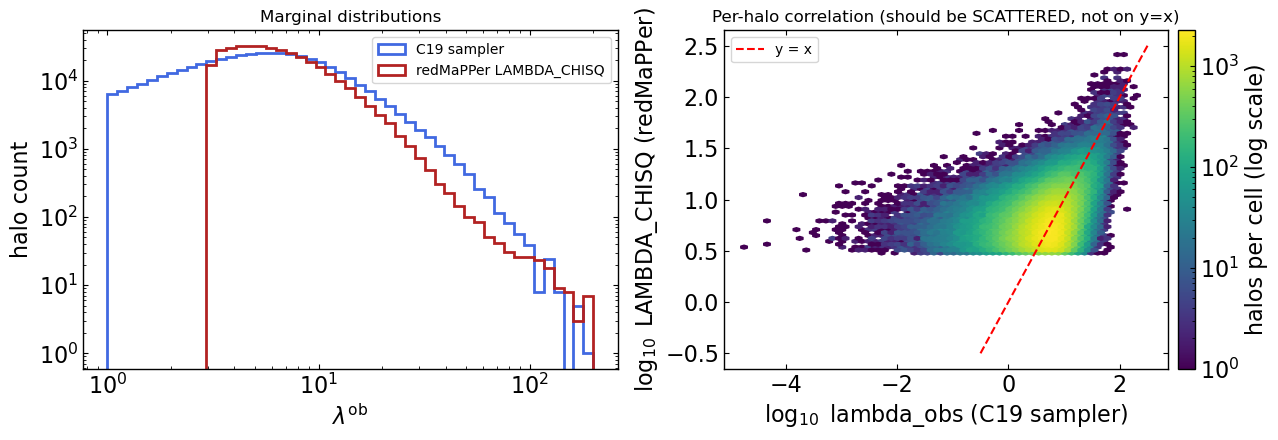

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: histograms of both definitions ---
ax = axes[0]
bins = np.logspace(0, 2.3, 50)   # log bins from lambda=1 to 200
ax.hist(lob_arr[lob_arr > 0],
        bins=bins, histtype='step', color='royalblue', lw=2,
        label='C19 sampler')
ax.hist(lam_RM[lam_RM > 0],
        bins=bins, histtype='step', color='firebrick', lw=2,
        label='redMaPPer LAMBDA_CHISQ')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\lambda^{\rm ob}$')
ax.set_ylabel('halo count')
ax.set_title('Marginal distributions')
ax.legend(loc='upper right')

# --- Right: scatter — does LAMBDA_CHISQ correlate with lambda_obs? ---
ax = axes[1]
m_valid = (lob_arr > 0) & (lam_RM > 0)
hb = ax.hexbin(np.log10(lob_arr[m_valid]),
          np.log10(lam_RM[m_valid]),
          gridsize=60, mincnt=1, cmap='viridis', bins='log')
ax.plot([-0.5, 2.5], [-0.5, 2.5], 'r--', lw=1.5, label='y = x')
ax.set_xlabel(r'$\log_{10}$ lambda_obs (C19 sampler)')
ax.set_ylabel(r'$\log_{10}$ LAMBDA_CHISQ (redMaPPer)')
ax.set_title(r'Per-halo correlation (should be SCATTERED, not on y=x)')
ax.legend()

cb = fig.colorbar(hb, ax=ax, pad=0.02)
cb.set_label('halos per cell (log scale)')

fig.tight_layout()
plt.show()

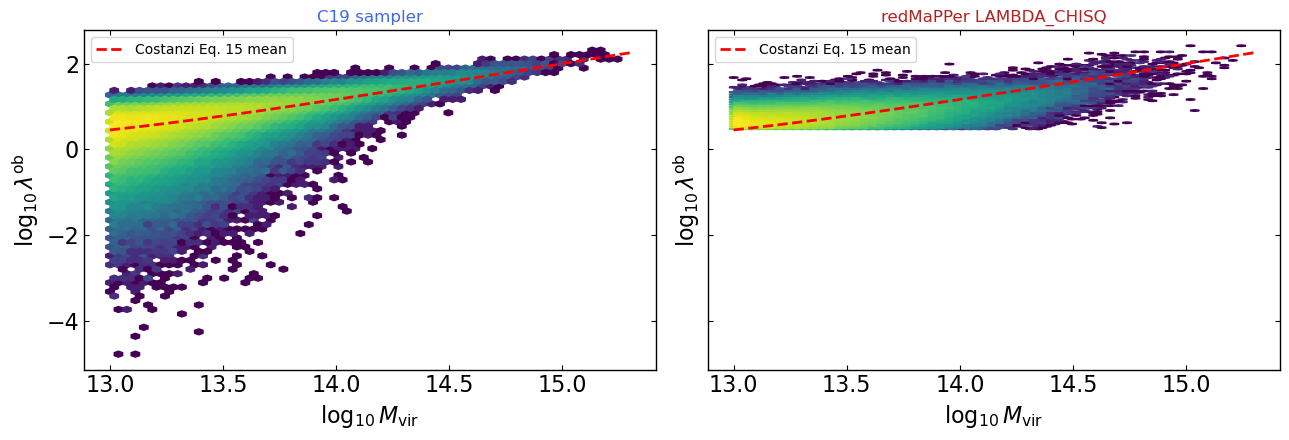

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)

# Costanzi Eq. 15 mean relation at z = 0.4 (a typical sample redshift)
M_grid = np.logspace(13, 15.3, 50)
lambda_mean = 1 + l_sat(M_grid, np.full_like(M_grid, 0.4))

for ax, lam, label, color in zip(
    axes,
    [lob_arr, lam_RM],
    ['C19 sampler', 'redMaPPer LAMBDA_CHISQ'],
    ['royalblue', 'firebrick'],
):
    m_valid = lam > 0
    ax.hexbin(logM_true[m_valid], np.log10(lam[m_valid]),
              gridsize=60, mincnt=1, cmap='viridis', bins='log')
    ax.plot(np.log10(M_grid), np.log10(lambda_mean), 'r--', lw=2,
            label='Costanzi Eq. 15 mean')
    ax.set_xlabel(r'$\log_{10} M_{\rm vir}$')
    ax.set_ylabel(r'$\log_{10} \lambda^{\rm ob}$')
    ax.set_title(label, color=color)
    ax.legend(loc='upper left')

fig.tight_layout()
plt.show()

In [42]:
print(np.min(lam_RM[lam_RM>0]), np.max(lam_RM[m_valid]))
print(np.min(lob_arr[lob_arr>0]), np.max(lob_arr[m_valid]))
print(np.log10(min(lam_RM[lam_RM>0])), np.log10(min(lob_arr[lob_arr>0])))

3.0094432830810547 259.18621826171875
1.709222860063475e-05 204.2986397439336
0.4784861628869138 -4.7672013073286115


In [43]:
# Heidi Wu's mass-redshift weighted reference profile.
from stacked_profile_weighted_by_mass_redshift import (
    stacked_profile_weighted_by_mass_redshift as mass_match_stack,
)


def stack_in_bins(lam, z, profile, lam_bins, z_min_list, z_max_list):
    """Plain mean profile per (lam, z) bin, plus per-bin selection mask list."""
    nl = len(lam_bins) - 1
    nz = len(z_min_list)
    nr = profile.shape[1]
    stacked = np.zeros((nl, nz, nr))
    counts  = np.zeros((nl, nz), dtype=int)
    masks   = [[None] * nz for _ in range(nl)]
    for il in range(nl):
        in_lam = (lam >= lam_bins[il]) & (lam < lam_bins[il + 1])
        for iz in range(nz):
            in_z = (z >= z_min_list[iz]) & (z < z_max_list[iz])
            m = in_lam & in_z
            masks[il][iz]    = m
            counts[il, iz]   = int(m.sum())
            if m.any():
                stacked[il, iz] = profile[m].mean(axis=0)
    return stacked, counts, masks


# --- Selected stack on (LAMBDA_CHISQ, Z_LAMBDA) bins ------------------------
DSigma_selected, N_sel, sel_masks = stack_in_bins(
    lam_RM, z_RM, DSigma, LBDBINS, ZMIN_LIST, ZMAX_LIST,
)

# --- Mass-matched random reference per bin ----------------------------------
# For each (lam_RM, z_RM) bin, build a reference whose (logM, z_true)
# distribution matches the selected sample's, with profile values drawn
# from the FULL mock (no optical selection).
DSigma_random = np.zeros_like(DSigma_selected)
shear_data_vector = np.zeros_like(DSigma_selected)
shear_random      = np.zeros_like(DSigma_selected)
B_sel_emp         = np.zeros_like(DSigma_selected)

for il in range(len(LBDBINS) - 1):
    for iz in range(len(ZMIN_LIST)):
        m = sel_masks[il][iz]
        if not m.any():
            continue

        DSigma_random[il, iz] = mass_match_stack(
            logM_true[m], z_true[m], DSigma[m],
            logM_true,    z_true,    DSigma,
            dm=0.1, dz=0.05,
        )

        z_rep     = float(np.mean(z_RM[m]))
        scinv_bin = float(np.interp(z_rep, zlens, sigma_crit_inv_vec_z))

        shear_data_vector[il, iz] = DSigma_selected[il, iz] * scinv_bin
        shear_random[il, iz]      = DSigma_random[il, iz]   * scinv_bin

        with np.errstate(divide='ignore', invalid='ignore'):
            B_sel_emp[il, iz] = np.where(
                DSigma_random[il, iz] != 0.0,
                DSigma_selected[il, iz] / DSigma_random[il, iz],
                np.nan,
            )

print('Halos per (LAMBDA_CHISQ, Z_LAMBDA) bin:')
print(N_sel)
print('B_sel_emp at R = 0.04, 1.0, 10.0 Mpc, bin (1, 1):')
i_R = np.searchsorted(radii, [0.04, 1.0, 10.0])
i_R = np.clip(i_R, 0, len(radii) - 1)
print(B_sel_emp[1, 1, i_R])


Halos per (LAMBDA_CHISQ, Z_LAMBDA) bin:
[[31137 74942 80092]
 [ 2096  6806  6272]
 [  397  1367  1019]
 [   97   381   235]]
B_sel_emp at R = 0.04, 1.0, 10.0 Mpc, bin (1, 1):
[1.08729252 1.07819117 1.38330533]


### Per-bin shear data vector and empirical $\mathcal{B}_\mathrm{sel}$

Top: stacked $|\gamma_t(R)|$ for the $\lambda^\mathrm{RM}$-selected sample vs the mass-matched random reference. Bottom: their ratio $\mathcal{B}_\mathrm{sel}^\mathrm{emp}(R)$ — the catalog analogue of C26 Eq. C1.

/tmp/ipykernel_1270470/1043841176.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


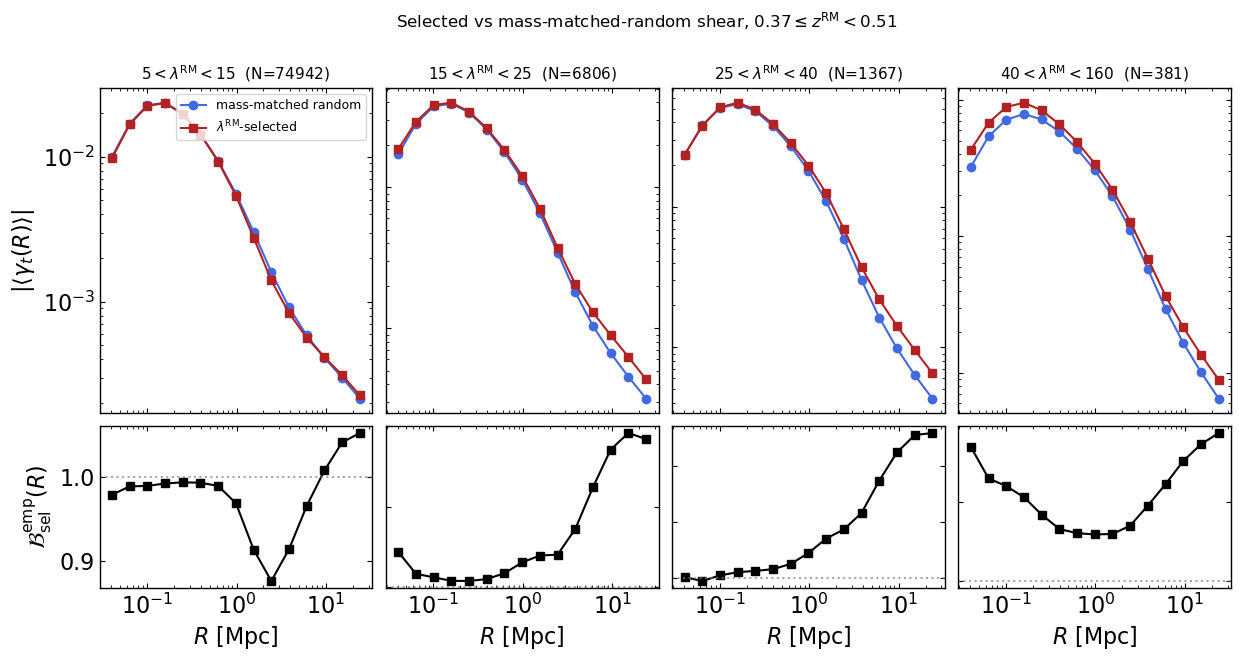

In [44]:
# --- Plot: selected vs mass-matched random shear, and the empirical B_sel ---

nl = len(LBDBINS) - 1
zb = 1   # which redshift bin to display

fig, axes = plt.subplots(
    2, nl, figsize=(nl * 3.4 + 1, 6.5),
    sharex=True,
    gridspec_kw={'hspace': 0.05, 'wspace': 0.05, 'height_ratios': [3, 1.5]},
)

for il in range(nl):
    ax_top = axes[0, il]
    ax_bot = axes[1, il]

    s_sel = shear_data_vector[il, zb]
    s_rnd = shear_random[il, zb]
    B_R   = B_sel_emp[il, zb]

    ax_top.loglog(radii, np.abs(s_rnd), 'o-', color='royalblue',
                   label=r'mass-matched random')
    ax_top.loglog(radii, np.abs(s_sel), 's-', color='firebrick',
                   label=r'$\lambda^{\rm RM}$-selected')

    ax_top.set_title(
        r'$%i < \lambda^{\rm RM} < %i$  (N=%d)' %
        (LBDBINS[il], LBDBINS[il + 1], N_sel[il, zb]),
        fontsize=11,
    )

    ax_bot.semilogx(radii, B_R, 's-', color='black')
    ax_bot.axhline(1.0, ls=':', color='gray', alpha=0.7)
    ax_bot.set_xlabel(r'$R\ [{\rm Mpc}]$')

    if il > 0:
        ax_top.tick_params(labelleft=False)
        ax_bot.tick_params(labelleft=False)

axes[0, 0].set_ylabel(r'$|\langle\gamma_t(R)\rangle|$')
axes[1, 0].set_ylabel(r'$\mathcal{B}_{\rm sel}^{\rm emp}(R)$')
axes[0, 0].legend(loc='upper right', fontsize=9)

fig.suptitle(
    r'Selected vs mass-matched-random shear, '
    r'$%.2f \leq z^{\rm RM} < %.2f$' % (ZMIN_LIST[zb], ZMAX_LIST[zb]),
    y=1.00, fontsize=12,
)
fig.tight_layout()
plt.show()

### Wu+2022 Fig. 2 reproduction — selection bias on $\Sigma$ vs $\Delta\Sigma$

Per $(\lambda^\mathrm{RM}, z^\mathrm{RM})$ bin, plot the selected/mass-matched ratio for both $\Sigma$ (orange) and $\Delta\Sigma$ (blue). Bell-shaped peak around $R \sim 1$ Mpc reproduces the LSS-environment bias signal in their figure.

/tmp/ipykernel_1270470/2842284447.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


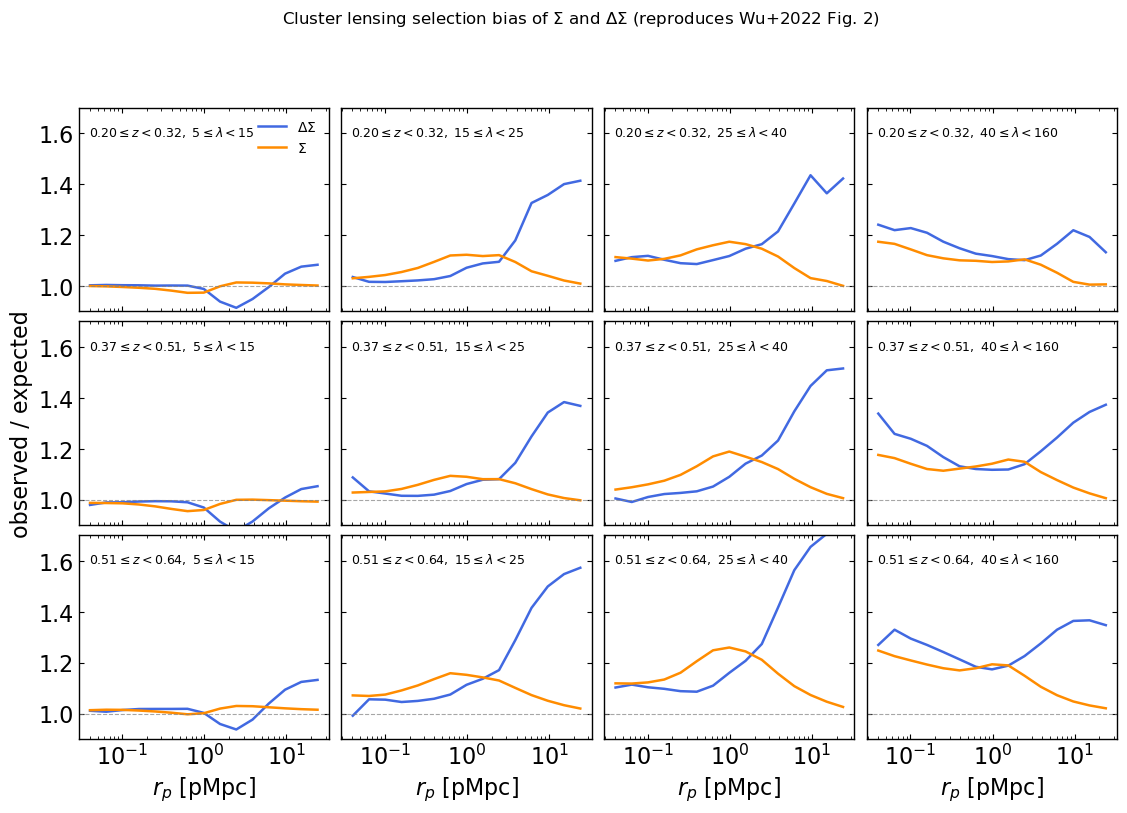

Median ratio per radial bin, averaged over (lambda, z):
  Sigma  : [1.055 1.059 1.067 1.083 1.103 1.111 1.125 1.132 1.129 1.125 1.097 1.063
 1.035 1.02  1.006]
  DSigma : [1.061 1.044 1.039 1.034 1.038 1.045 1.063 1.101 1.112 1.12  1.184 1.286
 1.35  1.365 1.371]


In [45]:
# === Wu+2022 Fig. 2 reproduction: selection bias of Sigma and DeltaSigma ====
# Wu+2022 Fig. 2 (arXiv:2203.05416) plots, for each (lambda, z) bin,
#   ratio = observed (richness-selected) / expected ((logM, z)-matched random)
# overlaid for two observables: Sigma (orange) and DeltaSigma (blue).
# The "expected" stack is built via Heidi Wu's mass-redshift weighting
# (their Appendix B, method iii), same as our DSigma_random above.
#
# We also build the Sigma equivalent from mock['Sigma'].

Sigma_all = np.asarray(mock['Sigma'])

# --- Stack Sigma on the same (LAMBDA_CHISQ, Z_LAMBDA) bins ------------------
Sigma_selected, _, _ = stack_in_bins(
    lam_RM, z_RM, Sigma_all, LBDBINS, ZMIN_LIST, ZMAX_LIST,
)

# --- (logM, z)-matched random Sigma reference per bin -----------------------
Sigma_random = np.zeros_like(Sigma_selected)
for il in range(len(LBDBINS) - 1):
    for iz in range(len(ZMIN_LIST)):
        m = sel_masks[il][iz]
        if not m.any():
            continue
        Sigma_random[il, iz] = mass_match_stack(
            logM_true[m], z_true[m], Sigma_all[m],
            logM_true,    z_true,    Sigma_all,
            dm=0.1, dz=0.05,
        )

# --- Ratios -----------------------------------------------------------------
with np.errstate(divide='ignore', invalid='ignore'):
    ratio_Sigma  = np.where(Sigma_random  != 0, Sigma_selected  / Sigma_random,  np.nan)
    ratio_DSigma = np.where(DSigma_random != 0, DSigma_selected / DSigma_random, np.nan)

# --- Plot: nz rows (redshift) x nl columns (richness) -----------------------
nl = len(LBDBINS) - 1
nz = len(ZMIN_LIST)

fig, axes = plt.subplots(
    nz, nl,
    figsize=(nl * 3.2 + 0.6, nz * 2.6 + 0.4),
    sharex=True, sharey=True,
    gridspec_kw={'hspace': 0.05, 'wspace': 0.05},
)

for iz in range(nz):
    for il in range(nl):
        ax = axes[iz, il]
        ax.semilogx(radii, ratio_DSigma[il, iz], '-', color='royalblue',
                     lw=1.8, label=r'$\Delta\Sigma$' if (iz == 0 and il == 0) else None)
        ax.semilogx(radii, ratio_Sigma [il, iz], '-', color='darkorange',
                     lw=1.8, label=r'$\Sigma$'      if (iz == 0 and il == 0) else None)
        ax.axhline(1.0, ls='--', color='gray', alpha=0.7, lw=0.8)

        # Wu+2022 Fig. 2 ranges and panel-title placement
        ax.set_ylim(0.9, 1.7)
        ax.text(
            0.04, 0.92,
            r'$%.2f \leq z < %.2f,\ %i \leq \lambda < %i$'
            % (ZMIN_LIST[iz], ZMAX_LIST[iz], LBDBINS[il], LBDBINS[il + 1]),
            transform=ax.transAxes, fontsize=9, va='top',
        )

# Outer-axis labelling and ticks
for il in range(nl):
    axes[-1, il].set_xlabel(r'$r_p\ [{\rm pMpc}]$')
for iz in range(nz):
    axes[nz // 2, 0].set_ylabel(r'observed / expected')

axes[0, 0].legend(loc='upper right', fontsize=10, frameon=False)

fig.suptitle(
    r'Cluster lensing selection bias of $\Sigma$ and $\Delta\Sigma$ '
    r'(reproduces Wu+2022 Fig. 2)',
    y=1.00, fontsize=12,
)
fig.tight_layout()
plt.show()


# --- Quick numeric summary ---
print("Median ratio per radial bin, averaged over (lambda, z):")
print("  Sigma  :", np.round(np.nanmedian(ratio_Sigma.reshape(-1, ratio_Sigma.shape[-1]),  axis=0), 3))
print("  DSigma :", np.round(np.nanmedian(ratio_DSigma.reshape(-1, ratio_DSigma.shape[-1]), axis=0), 3))

Running bootstrap (50 resamples per bin)...


  lam bin 0, z bin 0: N =  31137
  lam bin 0, z bin 1: N =  74942
  lam bin 0, z bin 2: N =  80092
  lam bin 1, z bin 0: N =   2096
  lam bin 1, z bin 1: N =   6806
  lam bin 1, z bin 2: N =   6272
  lam bin 2, z bin 0: N =    397
  lam bin 2, z bin 1: N =   1367
  lam bin 2, z bin 2: N =   1019
  lam bin 3, z bin 0: N =     97
  lam bin 3, z bin 1: N =    381
  lam bin 3, z bin 2: N =    235


/tmp/ipykernel_1270470/127031487.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


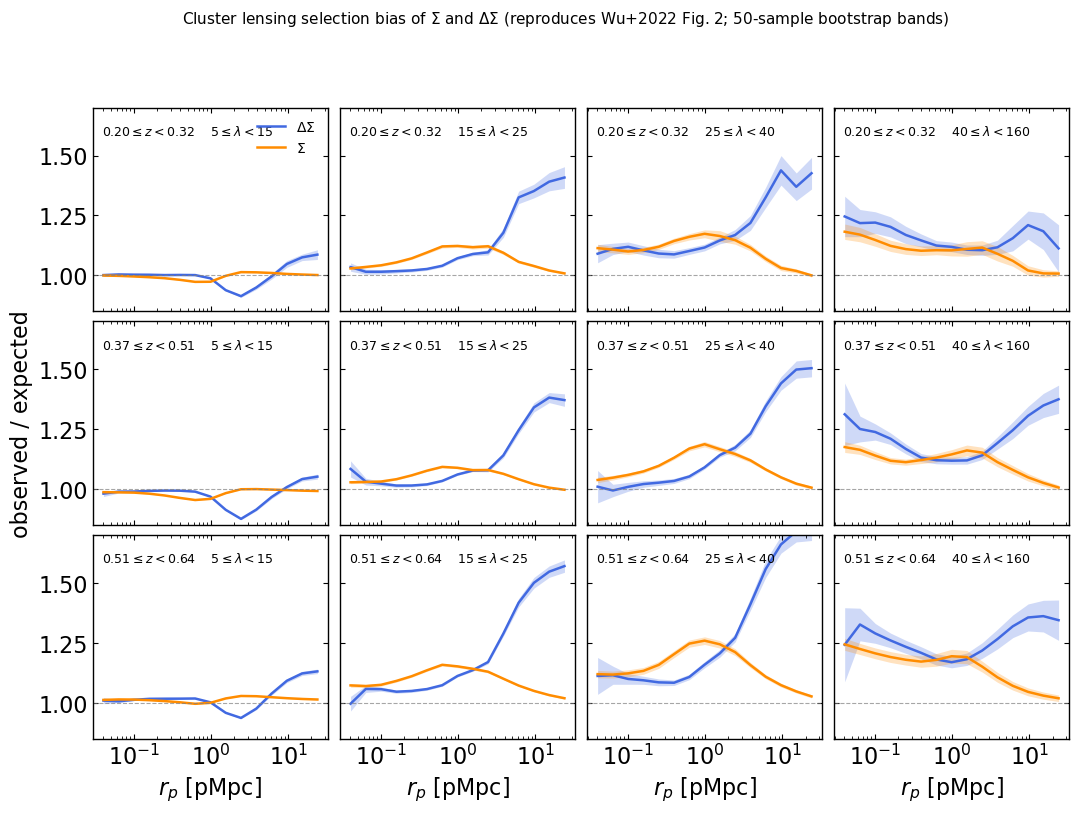

In [46]:
# === Wu+2022 Fig. 2 reproduction with bootstrap error bands =================
# Bootstrap the per-bin ratio (selected/expected) by resampling halos
# within each (lambda, z) bin. Captures the statistical uncertainty
# from finite halo count; for the lambda<15 bins this is the dominant
# source of the apparent dip and bump.

from itertools import product

N_BOOT = 50            # 50 is enough; 100+ gives smoother bands
DM_GRID = 0.1          # (logM, z) grid widths for matching
DZ_GRID = 0.05
rng_boot = np.random.default_rng(seed=0)


def bootstrap_ratio_one_bin(idx_sel, profile, logM_arr, z_arr,
                            n_boot, dm, dz, rng):
    """Bootstrap the selected/matched-random ratio for one (lambda, z) bin.

    idx_sel    : indices of halos in this bin
    profile    : (nh, nr) per-halo Sigma or DeltaSigma
    logM_arr   : (nh,) per-halo log10(M)
    z_arr      : (nh,) per-halo redshift (z_true for matching)
    Returns
    -------
    ratio_mean : (nr,)   bootstrap mean of the ratio
    ratio_std  : (nr,)   bootstrap std (the error band half-width)
    """
    n_sel = idx_sel.size
    nr    = profile.shape[1]
    if n_sel == 0:
        return np.full(nr, np.nan), np.full(nr, np.nan)

    ratios = np.empty((n_boot, nr))
    for b in range(n_boot):
        idx_b    = rng.choice(idx_sel, size=n_sel, replace=True)
        sel_mean = profile[idx_b].mean(axis=0)
        # Mass-matched reference for THIS bootstrap selection's (M, z) PDF
        rnd_mean = mass_match_stack(
            logM_arr[idx_b], z_arr[idx_b], profile[idx_b],
            logM_arr,        z_arr,        profile,
            dm=dm, dz=dz,
        )
        with np.errstate(divide='ignore', invalid='ignore'):
            ratios[b] = np.where(rnd_mean != 0, sel_mean / rnd_mean, np.nan)
    return np.nanmean(ratios, axis=0), np.nanstd(ratios, axis=0)


# Stack Sigma in (LAMBDA_CHISQ, Z_LAMBDA) bins — DeltaSigma already done in cell 25
Sigma_all = np.asarray(mock['Sigma'])
Sigma_selected, _, _ = stack_in_bins(
    lam_RM, z_RM, Sigma_all, LBDBINS, ZMIN_LIST, ZMAX_LIST,
)

# Allocate bootstrap arrays
nl, nz, nr = DSigma_selected.shape
ratio_DSigma_mean = np.full((nl, nz, nr), np.nan)
ratio_DSigma_std  = np.full((nl, nz, nr), np.nan)
ratio_Sigma_mean  = np.full((nl, nz, nr), np.nan)
ratio_Sigma_std   = np.full((nl, nz, nr), np.nan)

# Run bootstrap on every (lambda, z) bin for both observables
print('Running bootstrap (%d resamples per bin)...' % N_BOOT)
for il, iz in product(range(nl), range(nz)):
    idx_sel = np.where(sel_masks[il][iz])[0]
    if idx_sel.size == 0:
        continue
    ratio_DSigma_mean[il, iz], ratio_DSigma_std[il, iz] = bootstrap_ratio_one_bin(
        idx_sel, DSigma,    logM_true, z_true, N_BOOT, DM_GRID, DZ_GRID, rng_boot,
    )
    ratio_Sigma_mean[il, iz], ratio_Sigma_std[il, iz] = bootstrap_ratio_one_bin(
        idx_sel, Sigma_all, logM_true, z_true, N_BOOT, DM_GRID, DZ_GRID, rng_boot,
    )
    print(f'  lam bin {il}, z bin {iz}: N = {idx_sel.size:6d}')


# --- Plot: Wu+22 Fig. 2 reproduction with bootstrap bands ------------------
fig, axes = plt.subplots(
    nz, nl, figsize=(nl * 3.0 + 0.6, nz * 2.6 + 0.4),
    sharex=True, sharey=True,
    gridspec_kw={'hspace': 0.05, 'wspace': 0.05},
)

for iz in range(nz):
    for il in range(nl):
        ax = axes[iz, il]
        # DeltaSigma — blue line + shaded band
        ax.fill_between(
            radii,
            ratio_DSigma_mean[il, iz] - ratio_DSigma_std[il, iz],
            ratio_DSigma_mean[il, iz] + ratio_DSigma_std[il, iz],
            color='royalblue', alpha=0.25, lw=0,
        )
        ax.semilogx(radii, ratio_DSigma_mean[il, iz], '-',
                     color='royalblue', lw=1.8,
                     label=r'$\Delta\Sigma$' if (iz == 0 and il == 0) else None)

        # Sigma — orange line + shaded band
        ax.fill_between(
            radii,
            ratio_Sigma_mean[il, iz] - ratio_Sigma_std[il, iz],
            ratio_Sigma_mean[il, iz] + ratio_Sigma_std[il, iz],
            color='darkorange', alpha=0.25, lw=0,
        )
        ax.semilogx(radii, ratio_Sigma_mean[il, iz], '-',
                     color='darkorange', lw=1.8,
                     label=r'$\Sigma$' if (iz == 0 and il == 0) else None)

        ax.axhline(1.0, ls='--', color='gray', alpha=0.7, lw=0.8)
        ax.set_ylim(0.85, 1.7)
        ax.text(
            0.04, 0.92,
            r'$%.2f \leq z < %.2f$    $%i \leq \lambda < %i$'
            % (ZMIN_LIST[iz], ZMAX_LIST[iz], LBDBINS[il], LBDBINS[il + 1]),
            transform=ax.transAxes, fontsize=9, va='top',
        )

for il in range(nl):
    axes[-1, il].set_xlabel(r'$r_p\ [{\rm pMpc}]$')
axes[nz // 2, 0].set_ylabel(r'observed / expected')
axes[0, 0].legend(loc='upper right', fontsize=10, frameon=False)

fig.suptitle(
    r'Cluster lensing selection bias of $\Sigma$ and $\Delta\Sigma$ '
    r'(reproduces Wu+2022 Fig. 2; %d-sample bootstrap bands)' % N_BOOT,
    y=1.00, fontsize=11,
)
fig.tight_layout()
plt.show()

0 0 31137
0 1 74942
0 2 80092
1 0 2096
1 1 6806
1 2 6272
2 0 397
2 1 1367
2 2 1019
3 0 97
3 1 381
3 2 235


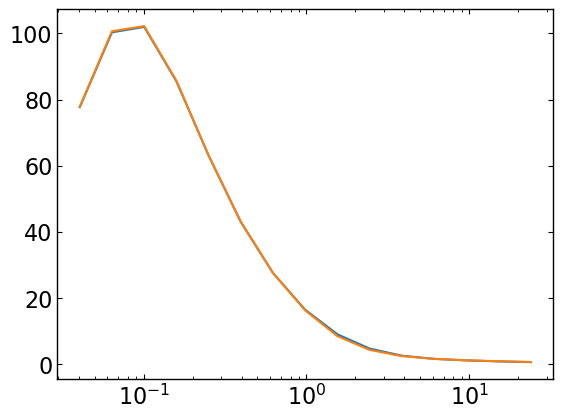

In [47]:
for il in range(len(LBDBINS)-1):
    for iz in range(len(ZMIN_LIST)):
        m = sel_masks[il][iz]
        print(il, iz, np.sum(m))
        
plt.semilogx(radii, DSigma_random[0,0])
plt.semilogx(radii, DSigma_selected[0,0])

### Null test — same plot but binning on the C19 sampler

Replace the redMaPPer richness with our environment-blind `lambda_obs`. The selected/mass-matched ratio should collapse to ≈ 1 at all $R$, confirming that the bell-shaped signal above is genuinely LSS-driven and not an artifact of the matching procedure.

/tmp/ipykernel_1270470/4137734966.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


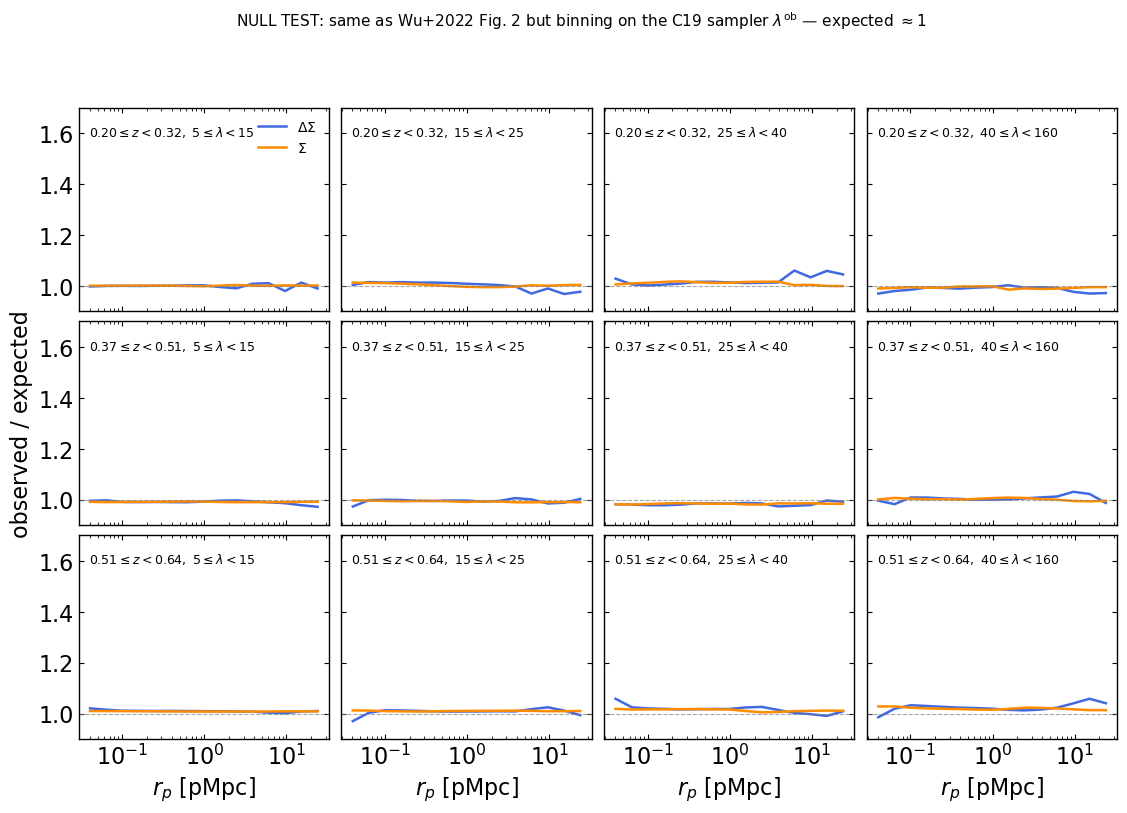

Median ratio per radial bin, averaged over (lambda, z):
  Sigma  : [1.003 1.008 1.007 1.005 1.004 1.001 1.001 1.002 1.004 1.004 1.001 1.001
 1.001 1.    1.   ]
  DSigma : [0.996 1.001 1.005 1.007 1.007 1.006 1.005 1.005 1.004 1.004 1.008 1.003
 0.993 1.002 0.993]


In [48]:
# === Same as the cell above, but binning the selected sample on the C19 ====
# forward-model lambda_obs (lob_arr, zob_arr) instead of the redMaPPer
# (LAMBDA_CHISQ, Z_LAMBDA). This ratio should be ~1 at all R because the
# C19 sampler doesn't carry per-halo LSS information -- a clean null test
# of the mass-matching procedure.

Sigma_all = np.asarray(mock['Sigma'])

# --- Stack on (lambda_obs, z_obs) bins --------------------------------------
DSigma_selected_C19, _, c19_masks = stack_in_bins(
    lob_arr, zob_arr, DSigma, LBDBINS, ZMIN_LIST, ZMAX_LIST,
)
Sigma_selected_C19, _, _ = stack_in_bins(
    lob_arr, zob_arr, Sigma_all, LBDBINS, ZMIN_LIST, ZMAX_LIST,
)

# --- (logM, z)-matched random references per bin -- using the C19 masks ----
DSigma_random_C19 = np.zeros_like(DSigma_selected_C19)
Sigma_random_C19  = np.zeros_like(Sigma_selected_C19)
for il in range(len(LBDBINS) - 1):
    for iz in range(len(ZMIN_LIST)):
        m = c19_masks[il][iz]
        if not m.any():
            continue
        DSigma_random_C19[il, iz] = mass_match_stack(
            logM_true[m], z_true[m], DSigma[m],
            logM_true,    z_true,    DSigma,
            dm=0.1, dz=0.05,
        )
        Sigma_random_C19[il, iz] = mass_match_stack(
            logM_true[m], z_true[m], Sigma_all[m],
            logM_true,    z_true,    Sigma_all,
            dm=0.1, dz=0.05,
        )

# --- Ratios -----------------------------------------------------------------
with np.errstate(divide='ignore', invalid='ignore'):
    ratio_Sigma_C19  = np.where(Sigma_random_C19  != 0,
                                Sigma_selected_C19  / Sigma_random_C19,  np.nan)
    ratio_DSigma_C19 = np.where(DSigma_random_C19 != 0,
                                DSigma_selected_C19 / DSigma_random_C19, np.nan)

# --- Plot: nz rows (redshift) x nl columns (richness) -----------------------
nl = len(LBDBINS) - 1
nz = len(ZMIN_LIST)

fig, axes = plt.subplots(
    nz, nl,
    figsize=(nl * 3.2 + 0.6, nz * 2.6 + 0.4),
    sharex=True, sharey=True,
    gridspec_kw={'hspace': 0.05, 'wspace': 0.05},
)

for iz in range(nz):
    for il in range(nl):
        ax = axes[iz, il]
        ax.semilogx(radii, ratio_DSigma_C19[il, iz], '-', color='royalblue',
                     lw=1.8, label=r'$\Delta\Sigma$' if (iz == 0 and il == 0) else None)
        ax.semilogx(radii, ratio_Sigma_C19 [il, iz], '-', color='darkorange',
                     lw=1.8, label=r'$\Sigma$'      if (iz == 0 and il == 0) else None)
        ax.axhline(1.0, ls='--', color='gray', alpha=0.7, lw=0.8)

        ax.set_ylim(0.9, 1.7)
        ax.text(
            0.04, 0.92,
            r'$%.2f \leq z < %.2f,\ %i \leq \lambda < %i$'
            % (ZMIN_LIST[iz], ZMAX_LIST[iz], LBDBINS[il], LBDBINS[il + 1]),
            transform=ax.transAxes, fontsize=9, va='top',
        )

# Outer-axis labelling
for il in range(nl):
    axes[-1, il].set_xlabel(r'$r_p\ [{\rm pMpc}]$')
axes[nz // 2, 0].set_ylabel(r'observed / expected')

axes[0, 0].legend(loc='upper right', fontsize=10, frameon=False)

fig.suptitle(
    r'NULL TEST: same as Wu+2022 Fig. 2 but binning on the C19 sampler '
    r'$\lambda^{\rm ob}$ — expected $\approx 1$',
    y=1.00, fontsize=11,
)
fig.tight_layout()
plt.show()


# --- Quick numeric summary ---
print("Median ratio per radial bin, averaged over (lambda, z):")
print("  Sigma  :", np.round(np.nanmedian(
    ratio_Sigma_C19.reshape(-1, ratio_Sigma_C19.shape[-1]),  axis=0), 3))
print("  DSigma :", np.round(np.nanmedian(
    ratio_DSigma_C19.reshape(-1, ratio_DSigma_C19.shape[-1]), axis=0), 3))

## 7.5 Analytical Costanzi+2026 Eq. C1 correction on $\Delta\Sigma$ (C19 $\lambda^\mathrm{ob}$ route)

A purely analytical alternative to §7's catalog-empirical ratio. Matteo
reports (private communication) that the **same C1 functional form** also
fits the bias on $\Delta\Sigma$, with a different parameter set:

$$
\mathcal{B}^{\Delta\Sigma}_\mathrm{C1}(R) =
A\,\left(\frac{R}{R_0}\right)^{\alpha}
\left[\,1 + \left(\frac{R}{R_0}\right)^{\gamma}\,\right]^{(\beta-\alpha)/\gamma}
+ C,
$$

with the mean-fit constants
$(A, \alpha, \beta, \gamma, C) = (0.12,\; 4.11,\; -0.18,\; 1.82,\; 1.00)$
and $R_0 = R_\lambda(1 + z)$, $R_\lambda = (\lambda^\mathrm{ob}/100)^{0.2}\,h^{-1}\,\mathrm{Mpc}$
(C26 Appendix B). The data vector is then

$$
\Delta\Sigma_\mathrm{obs}(R)
= \mathcal{B}^{\Delta\Sigma}_\mathrm{C1}(R;\, \lambda^\mathrm{ob}, z)\;\Delta\Sigma_\mathrm{true}(R),
\qquad
\langle\gamma_t(R)\rangle = \Delta\Sigma_\mathrm{obs}(R)\,\Sigma_\mathrm{crit}^{-1}(\langle z^\mathrm{ob}\rangle_\mathrm{bin}).
$$

We bin $\Delta\Sigma_\mathrm{true}$ on the **C19 forward-model**
`lambda_obs` / `redshift_obs` (the kernel-driven surrogate from §4), so the
chain $\lambda^\mathrm{tr} \to \lambda^\mathrm{ob} \to \Delta\Sigma_\mathrm{obs}$
lives entirely in the analytical-model world — distinct from §7 which
stacks on the catalog redMaPPer outputs.

This is the "cheap analytical alternative" Matteo recommends for MCMC:
the full C26 forward model ($\Sigma_{1h}$ via Eq. 12 + $\Sigma_\mathrm{prj}$
via Eq. 13, then Wright-Brainerd to $\Delta\Sigma$) involves nested
line-of-sight integrals through the optical-bias kernel
$b_{\lambda^\mathrm{ob}}$ (Eq. 8) that are prohibitive at every likelihood
evaluation. The C1 fit collapses that calculation into five constants.

B_C1^DSigma at R = [0.04, 0.3, 1.0, 3.0, 10.0] Mpc, lambda=30, z=0.3:
[1.00000013 1.00043112 1.01840935 1.06983743 1.07749691]
B_C1^Sigma  at R = [0.04, 0.3, 1.0, 3.0, 10.0] Mpc, lambda=30, z=0.3:
[1.00465152 1.02964607 1.07575843 1.0590324  1.03138002]


/tmp/ipykernel_1270470/2249853035.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


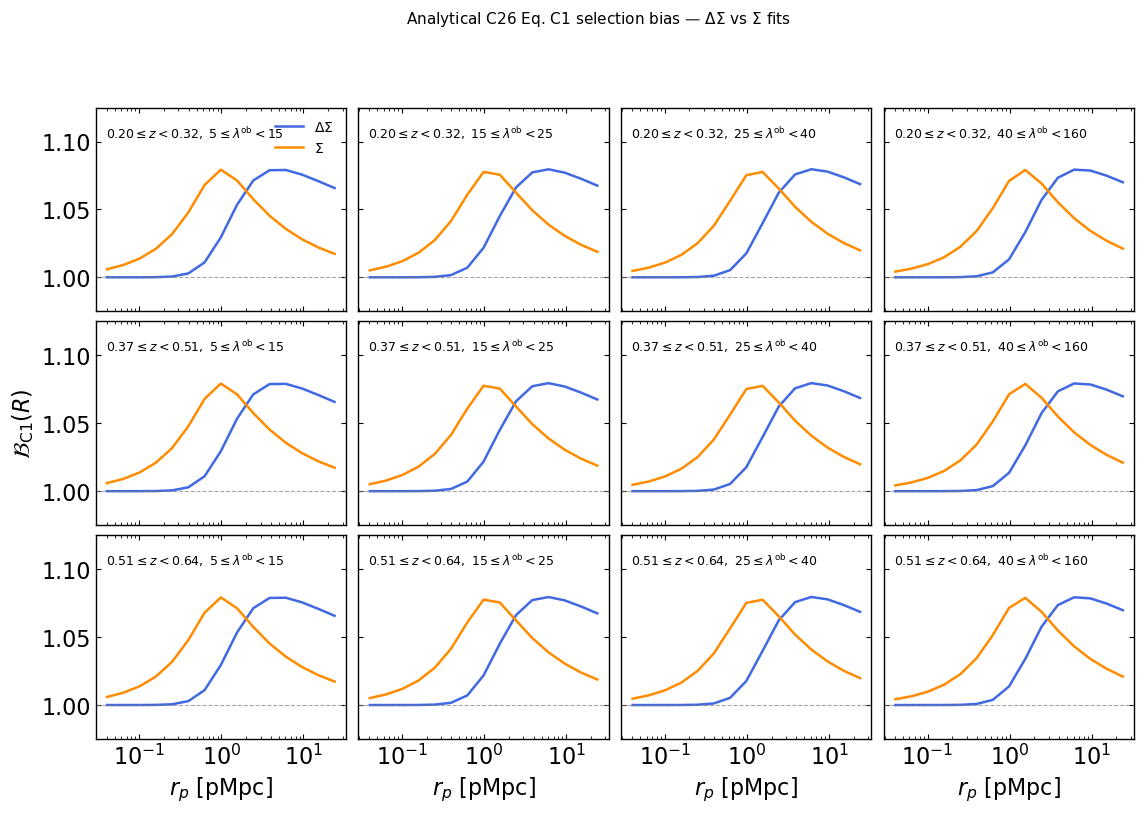

/tmp/ipykernel_1270470/2249853035.py:166: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


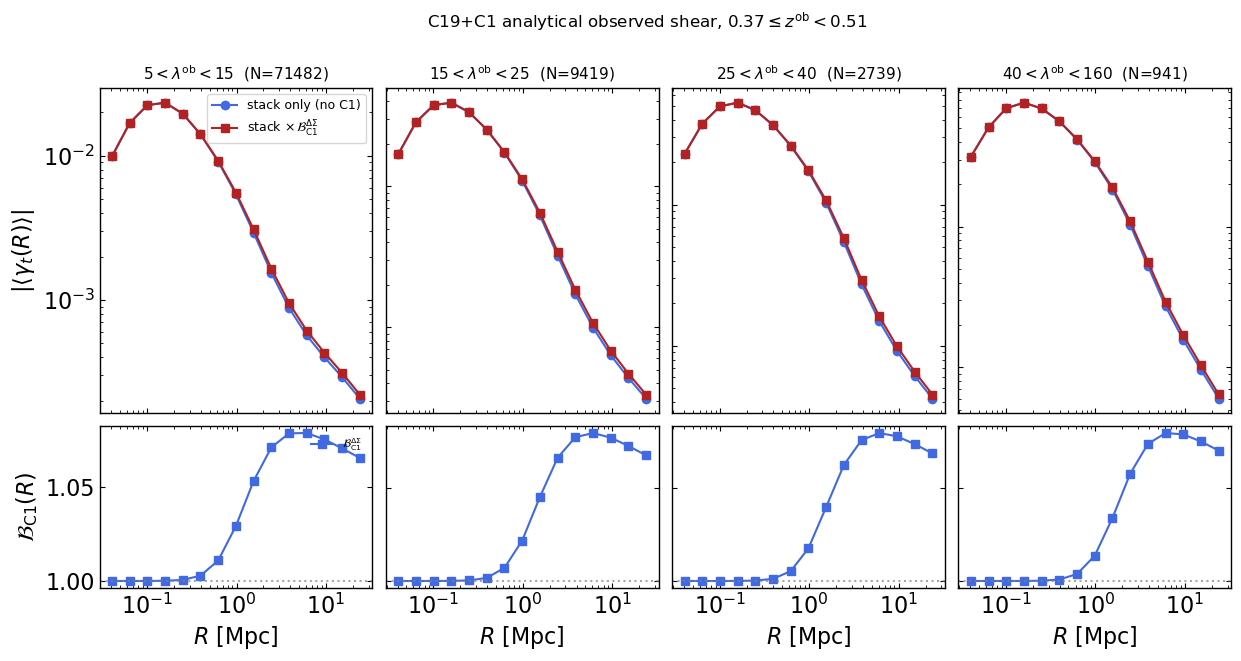

In [49]:
# === §7.5 — analytical C1 correction applied to DeltaSigma_true (C19 route) ===
# Matteo's mean-fit constants (private comm.) for the bias on DeltaSigma:
A_DS, ALPHA_DS, BETA_DS, GAMMA_DS, C_DS = 0.12, 4.11, -0.18, 1.82, 1.00

# C26 Appendix C published constants for the bias on Sigma (paper p. 12).
# Note: their Eq. C1 has "+1" rather than a free C constant, which is the
# C = 1 limit of the ΔΣ form below.
A_S, ALPHA_S, BETA_S, GAMMA_S, C_S = 0.10, 0.92, -0.53, 4.1, 1.00


def _Bsel_C1(R_phys_mpc, lambda_rep, z_rep, A, alpha, beta, gamma, C, h):
    """Generic C26 Eq. C1 form. Inputs: R in physical Mpc, lambda, z,
    parameters A/alpha/beta/gamma/C, and little-h. R_0 = R_lambda*(1+z)
    in comoving Mpc/h (App. B); R is converted internally."""
    R_phys_mpc = np.asarray(R_phys_mpc, dtype=float)
    R_cMpc_h   = R_phys_mpc * (1.0 + z_rep) * h
    R0         = (lambda_rep / 100.0) ** 0.2 * (1.0 + z_rep)
    x          = R_cMpc_h / R0
    return A * x ** alpha * (1.0 + x ** gamma) ** ((beta - alpha) / gamma) + C


def Bsel_C1_DSigma(R_phys_mpc, lambda_rep, z_rep, h=None):
    if h is None:
        h = cosmo0.h
    return _Bsel_C1(R_phys_mpc, lambda_rep, z_rep,
                    A_DS, ALPHA_DS, BETA_DS, GAMMA_DS, C_DS, h)


def Bsel_C1_Sigma(R_phys_mpc, lambda_rep, z_rep, h=None):
    if h is None:
        h = cosmo0.h
    return _Bsel_C1(R_phys_mpc, lambda_rep, z_rep,
                    A_S, ALPHA_S, BETA_S, GAMMA_S, C_S, h)


# --- Stack DeltaSigma_true on the C19 (lambda_obs, z_obs) bins -------------
DSigma_lob_C19, N_lob_C19, lob_masks = stack_in_bins(
    lob_arr, zob_arr, DSigma, LBDBINS, ZMIN_LIST, ZMAX_LIST,
)

# --- Per-bin analytical biases (DSigma + Sigma) and observed shear ---------
Bsel_DSigma_C1   = np.zeros_like(DSigma_lob_C19)
Bsel_Sigma_C1    = np.zeros_like(DSigma_lob_C19)
DSigma_obs_C1    = np.zeros_like(DSigma_lob_C19)
shear_C19_C1     = np.zeros_like(DSigma_lob_C19)
shear_C19_stack  = np.zeros_like(DSigma_lob_C19)   # no-correction reference

for il in range(len(LBDBINS) - 1):
    for iz in range(len(ZMIN_LIST)):
        m = lob_masks[il][iz]
        if not m.any():
            continue

        lam_rep = float(np.mean(lob_arr[m]))
        z_rep   = float(np.mean(zob_arr[m]))

        Bsel_DSigma_C1[il, iz] = Bsel_C1_DSigma(radii, lam_rep, z_rep)
        Bsel_Sigma_C1 [il, iz] = Bsel_C1_Sigma (radii, lam_rep, z_rep)
        DSigma_obs_C1 [il, iz] = DSigma_lob_C19[il, iz] * Bsel_DSigma_C1[il, iz]

        scinv_bin = float(np.interp(z_rep, zlens, sigma_crit_inv_vec_z))
        shear_C19_stack[il, iz] = DSigma_lob_C19[il, iz] * scinv_bin
        shear_C19_C1   [il, iz] = DSigma_obs_C1 [il, iz] * scinv_bin


# --- Sanity printout -------------------------------------------------------
R_grid = np.array([0.04, 0.3, 1.0, 3.0, 10.0])
print('B_C1^DSigma at R = %s Mpc, lambda=30, z=0.3:' % R_grid.tolist())
print(Bsel_C1_DSigma(R_grid, 30.0, 0.3))
print('B_C1^Sigma  at R = %s Mpc, lambda=30, z=0.3:' % R_grid.tolist())
print(Bsel_C1_Sigma (R_grid, 30.0, 0.3))


# --- Plot 1 -- analytical C1 selection bias panel grid (DSigma vs Sigma) ---
nl = len(LBDBINS) - 1
nz = len(ZMIN_LIST)

fig, axes = plt.subplots(
    nz, nl,
    figsize=(nl * 3.2 + 0.6, nz * 2.6 + 0.4),
    sharex=True, sharey=True,
    gridspec_kw={'hspace': 0.05, 'wspace': 0.05},
)

for iz in range(nz):
    for il in range(nl):
        ax = axes[iz, il]
        ax.semilogx(radii, Bsel_DSigma_C1[il, iz], '-', color='royalblue',
                     lw=1.8, label=r'$\Delta\Sigma$' if (iz == 0 and il == 0) else None)
        ax.semilogx(radii, Bsel_Sigma_C1 [il, iz], '-', color='darkorange',
                     lw=1.8, label=r'$\Sigma$'      if (iz == 0 and il == 0) else None)
        ax.axhline(1.0, ls='--', color='gray', alpha=0.7, lw=0.8)

        ax.set_ylim(0.9, 1.7)
        ax.text(
            0.04, 0.92,
            r'$%.2f \leq z < %.2f,\ %i \leq \lambda^{\rm ob} < %i$'
            % (ZMIN_LIST[iz], ZMAX_LIST[iz], LBDBINS[il], LBDBINS[il + 1]),
            transform=ax.transAxes, fontsize=9, va='top',
        )

for il in range(nl):
    axes[-1, il].set_xlabel(r'$r_p\ [{\rm pMpc}]$')
axes[nz // 2, 0].set_ylabel(r'$\mathcal{B}_{\rm C1}(R)$')
axes[0, 0].legend(loc='upper right', fontsize=10, frameon=False)

fig.suptitle(
    r'Analytical C26 Eq. C1 selection bias — $\Delta\Sigma$ vs $\Sigma$ fits',
    y=1.00, fontsize=11,
)
fig.tight_layout()
plt.ylim(0.975, 1.125)
plt.show()


# --- Plot 2 -- observed shear, with vs without C1 correction ---------------
zb = 1   # which redshift bin to display

fig, axes = plt.subplots(
    2, nl, figsize=(nl * 3.4 + 1, 6.5),
    sharex=True,
    gridspec_kw={'hspace': 0.05, 'wspace': 0.05, 'height_ratios': [3, 1.5]},
)

for il in range(nl):
    ax_top = axes[0, il]
    ax_bot = axes[1, il]

    s_stack = shear_C19_stack[il, zb]
    s_obs   = shear_C19_C1   [il, zb]
    B_DS    = Bsel_DSigma_C1 [il, zb]
    B_S     = Bsel_Sigma_C1  [il, zb]

    ax_top.loglog(radii, np.abs(s_stack), 'o-', color='royalblue',
                   label=r'stack only (no C1)')
    ax_top.loglog(radii, np.abs(s_obs),   's-', color='firebrick',
                   label=r'stack $\times\,\mathcal{B}^{\Delta\Sigma}_{\rm C1}$')

    ax_top.set_title(
        r'$%i < \lambda^{\rm ob} < %i$  (N=%d)' %
        (LBDBINS[il], LBDBINS[il + 1], N_lob_C19[il, zb]),
        fontsize=11,
    )

    ax_bot.semilogx(radii, B_DS, 's-', color='royalblue',
                     label=r'$\mathcal{B}^{\Delta\Sigma}_{\rm C1}$' if il == 0 else None)
    #ax_bot.semilogx(radii, B_S,  '-', color='darkorange',
    #                 label=r'$\mathcal{B}^{\Sigma}_{\rm C1}$' if il == 0 else None)
    ax_bot.axhline(1.0, ls=':', color='gray', alpha=0.7)
    ax_bot.set_xlabel(r'$R\ [{\rm Mpc}]$')

    if il > 0:
        ax_top.tick_params(labelleft=False)
        ax_bot.tick_params(labelleft=False)

axes[0, 0].set_ylabel(r'$|\langle\gamma_t(R)\rangle|$')
axes[1, 0].set_ylabel(r'$\mathcal{B}_{\rm C1}(R)$')
axes[0, 0].legend(loc='upper right', fontsize=9)
axes[1, 0].legend(loc='upper right', fontsize=8, frameon=False)

fig.suptitle(
    r'C19+C1 analytical observed shear, '
    r'$%.2f \leq z^{\rm ob} < %.2f$' % (ZMIN_LIST[zb], ZMAX_LIST[zb]),
    y=1.00, fontsize=12,
)
fig.tight_layout()
plt.show()

/tmp/ipykernel_1270470/1410106275.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


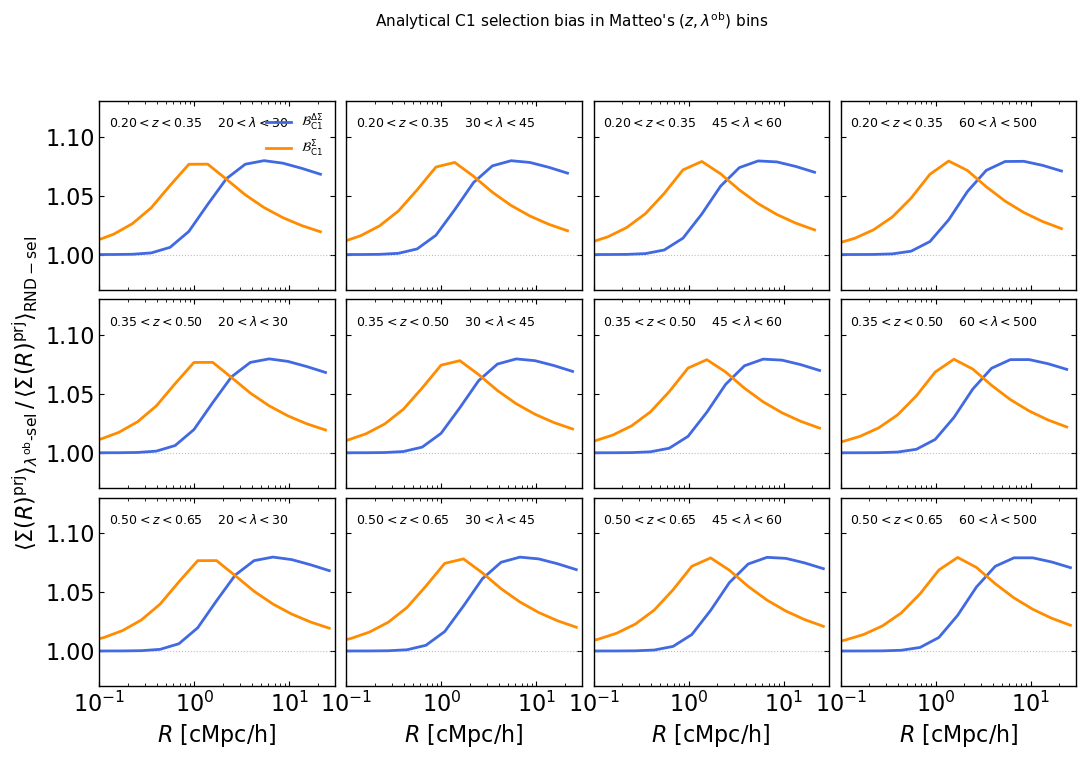

In [50]:
# === §7.6 — analytical C1 in Matteo's panel layout, his bins, his axes ====

h = cosmo0.h

# Matteo's bin edges
LBDBINS_M  = np.array([20, 30, 45, 60, 500])
ZMIN_LIST_M = np.array([0.20, 0.35, 0.50])
ZMAX_LIST_M = np.array([0.35, 0.50, 0.65])

# Use his bins for halo selection; need to re-stack the C19 sample on these.
lob_masks_M  = [[None] * len(ZMIN_LIST_M) for _ in range(len(LBDBINS_M) - 1)]
Bsel_DSigma_C1_M = np.zeros(
    (len(LBDBINS_M) - 1, len(ZMIN_LIST_M), len(radii))
)
Bsel_Sigma_C1_M = np.zeros_like(Bsel_DSigma_C1_M)

for il in range(len(LBDBINS_M) - 1):
    in_lam = (lob_arr >= LBDBINS_M[il]) & (lob_arr < LBDBINS_M[il + 1])
    for iz in range(len(ZMIN_LIST_M)):
        in_z = (zob_arr >= ZMIN_LIST_M[iz]) & (zob_arr < ZMAX_LIST_M[iz])
        m = in_lam & in_z
        lob_masks_M[il][iz] = m
        if not m.any():
            continue
        lam_rep = float(np.mean(lob_arr[m]))
        z_rep   = float(np.mean(zob_arr[m]))
        Bsel_DSigma_C1_M[il, iz] = Bsel_C1_DSigma(radii, lam_rep, z_rep)
        Bsel_Sigma_C1_M [il, iz] = Bsel_C1_Sigma (radii, lam_rep, z_rep)


# --- Plot in Matteo's layout: nz rows × nl columns ------------------------
nl = len(LBDBINS_M) - 1
nz = len(ZMIN_LIST_M)

fig, axes = plt.subplots(
    nz, nl,
    figsize=(nl * 3.0 + 0.6, nz * 2.4 + 0.4),
    sharex=True, sharey=True,
    gridspec_kw={'hspace': 0.05, 'wspace': 0.05},
)

for iz in range(nz):
    for il in range(nl):
        ax = axes[iz, il]

        m = lob_masks_M[il][iz]
        if not m.any():
            continue
        z_rep    = float(np.mean(zob_arr[m]))
        R_cMpc_h = radii * (1.0 + z_rep) * h

        ax.semilogx(R_cMpc_h, Bsel_DSigma_C1_M[il, iz], '-',
                     color='royalblue', lw=2.0,
                     label=r'$\mathcal{B}^{\Delta\Sigma}_{\rm C1}$'
                           if (iz == 0 and il == 0) else None)
        ax.semilogx(R_cMpc_h, Bsel_Sigma_C1_M[il, iz], '-',
                     color='darkorange', lw=2.0,
                     label=r'$\mathcal{B}^{\Sigma}_{\rm C1}$'
                           if (iz == 0 and il == 0) else None)

        ax.axhline(1.0, ls=':', color='gray', alpha=0.5, lw=0.8)
        ax.set_ylim(0.97, 1.13)                          # match Matteo's range
        ax.set_xlim(1e-1, 3e1)                            # match Matteo's range

        ax.text(
            0.04, 0.92,
            r'$%.2f < z < %.2f$    $%i < \lambda < %i$'
            % (ZMIN_LIST_M[iz], ZMAX_LIST_M[iz], LBDBINS_M[il], LBDBINS_M[il + 1]),
            transform=ax.transAxes, fontsize=9, va='top',
        )

for il in range(nl):
    axes[-1, il].set_xlabel(r'$R\ [{\rm cMpc/h}]$')
axes[nz // 2, 0].set_ylabel(
    r'$\langle\Sigma(R)^{\rm prj}\rangle_{\lambda^{\rm ob}\text{-sel}}'
    r'\,/\,\langle\Sigma(R)^{\rm prj}\rangle_{\rm RND-sel}$'
)
axes[0, 0].legend(loc='upper right', fontsize=9, frameon=False)

fig.suptitle(r"Analytical C1 selection bias in Matteo's $(z, \lambda^{\rm ob})$ bins",
             y=1.00, fontsize=11)
fig.tight_layout()
plt.show()

## 8. Save the data vector

Persist the full data vector to `/global/u2/x/xintang/mocks/mock/` as a single
`.npz` archive — the C19 forward-model number counts
$N(\lambda^\mathrm{ob}, z^\mathrm{ob})$, the §7 catalog-driven shear vector
with the empirical $\mathcal{B}_\mathrm{sel}^\mathrm{emp}(R)$ ratio, and the
§7.5 analytical C1 corrections (`Bsel_DSigma_C1`, `shear_C19_C1`).

In [51]:
out_dir = '/global/u2/x/xintang/mocks/mock'
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'Xin_MockDataVector.npz')

np.savez(
    out_path,
    radii_phys_mpc=np.asarray(radii),
    lambda_bins=np.asarray(LBDBINS),
    z_bin_min=np.asarray(ZMIN_LIST),
    z_bin_max=np.asarray(ZMAX_LIST),
    number_counts=nc_obs,                    # (n_lam, n_z), C19 forward model (lambda_obs, redshift_obs)
    counts_per_bin=N_sel,                    # (n_lam, n_z), redMaPPer (LAMBDA_CHISQ, Z_LAMBDA)

    # --- §7: catalog redMaPPer + mass-matched ratio path ---
    DSigma_selected=DSigma_selected,         # (n_lam, n_z, n_r)
    DSigma_random=DSigma_random,             # (n_lam, n_z, n_r), mass-matched reference
    B_sel_emp=B_sel_emp,                     # (n_lam, n_z, n_r), empirical Costanzi B_sel ratio
    shear_data_vector=shear_data_vector,     # (n_lam, n_z, n_r), DSigma_selected * Sigma_crit^-1
    shear_random=shear_random,               # (n_lam, n_z, n_r), reference shear (no selection bias)

    # --- §7.5: C19 forward model + analytical C1 on DeltaSigma ---
    DSigma_lob_C19=DSigma_lob_C19,           # (n_lam, n_z, n_r), DeltaSigma stacked on C19 (lambda_obs, z_obs)
    Bsel_DSigma_C1=Bsel_DSigma_C1,           # (n_lam, n_z, n_r), C26 Eq. C1 fit for DeltaSigma
    Bsel_Sigma_C1=Bsel_Sigma_C1,             # (n_lam, n_z, n_r), C26 Eq. C1 fit for Sigma (overlay)
    DSigma_obs_C1=DSigma_obs_C1,             # (n_lam, n_z, n_r), DSigma_lob_C19 * Bsel_DSigma_C1
    shear_C19_C1=shear_C19_C1,               # (n_lam, n_z, n_r), analytical observed shear
    shear_C19_stack=shear_C19_stack,         # (n_lam, n_z, n_r), no-correction reference (C19 stack only)
)

print('Saved data vector to: %s' % out_path)


Saved data vector to: /global/u2/x/xintang/mocks/mock/Xin_MockDataVector.npz


1. where is the lambda comes from?
    